<a href="https://colab.research.google.com/github/Ajendra11/Concepts-and-Technologies-of-AI/blob/main/2501936_Ajendra_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **3.1    Classification Task :**

## **1. Exploratory Data Analysis and Data Understanding:**

### **1. Choosing a Dataset**

In [3]:
import pandas as pd

#Loading the dataset into a pandas DataFrame.
df = pd.read_csv('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/smoking_driking_dataset_Ver01.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991346 non-null  object 
 1   age               991346 non-null  int64  
 2   height            991346 non-null  int64  
 3   weight            991346 non-null  int64  
 4   waistline         991346 non-null  float64
 5   sight_left        991346 non-null  float64
 6   sight_right       991346 non-null  float64
 7   hear_left         991346 non-null  float64
 8   hear_right        991346 non-null  float64
 9   SBP               991346 non-null  float64
 10  DBP               991346 non-null  float64
 11  BLDS              991346 non-null  float64
 12  tot_chole         991346 non-null  float64
 13  HDL_chole         991346 non-null  float64
 14  LDL_chole         991346 non-null  float64
 15  triglyceride      991346 non-null  float64
 16  hemoglobin        99

(a) Creation Details

Compiled and uploaded by Soo.Y (Kaggle username: sooyoungher). The data originates from large-scale health examinations conducted by the National Health Insurance Service (NHIS) in Korea. It was processed to exclude any identifiable or sensitive personal details. Initial upload to Kaggle appears to date back to around 2022–2023 (updated ~2 years ago as of recent checks), and it remains a static dataset derived from historical screening records.

(b) Access Method

Downloaded as smoking_driking_dataset_Ver01.csv (~29–110 MB depending on compression/view; full CSV ~109 MB) from Kaggle. Contains approximately 991,346 rows (country-year equivalent: individual health records) and 24 columns (23 features + targets).

(c) UNSDG Alignment

Goal 3: Good Health and Well-being aims to ensure healthy lives and promote well-being for all at all ages. Key targets include:

3.4 By 2030, reduce by one third premature mortality from non-communicable diseases through prevention and treatment and promote mental health and well-being.

3.5 Strengthen the prevention and treatment of substance abuse, including narcotic drug abuse and harmful use of alcohol.

3.a Strengthen the implementation of the World Health Organization Framework Convention on Tobacco Control in all countries, as appropriate.

Goal 3 is directly supported, as smoking and excessive alcohol consumption are major modifiable risk factors for non-communicable diseases (e.g., cardiovascular disease, cancer, liver disease). The dataset enables modeling and insights into predictors of these behaviors using body signals (e.g., blood markers, anthropometrics), which can inform prevention strategies, early detection, public health policies, and awareness efforts to reduce harmful use of tobacco and alcohol. It indirectly connects to broader goals like reducing inequalities in health outcomes through data-driven interventions.3sFast20 sources

In [4]:
print("Descriptive statistics for numerical columns:")
print(df.describe())

Descriptive statistics for numerical columns:
                 age         height         weight      waistline  \
count  991346.000000  991346.000000  991346.000000  991346.000000   
mean       47.614491     162.240625      63.284050      81.233358   
std        14.181339       9.282957      12.514241      11.850323   
min        20.000000     130.000000      25.000000       8.000000   
25%        35.000000     155.000000      55.000000      74.100000   
50%        45.000000     160.000000      60.000000      81.000000   
75%        60.000000     170.000000      70.000000      87.800000   
max        85.000000     190.000000     140.000000     999.000000   

          sight_left    sight_right      hear_left     hear_right  \
count  991346.000000  991346.000000  991346.000000  991346.000000   
mean        0.980834       0.978429       1.031495       1.030476   
std         0.605949       0.604774       0.174650       0.171892   
min         0.100000       0.100000       1.000000      

In [5]:
print("Unique values and counts for categorical columns:")
for col in ['sex', 'DRK_YN', 'SMK_stat_type_cd']:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Unique values and counts for categorical columns:

Column: sex
sex
Male      526415
Female    464931
Name: count, dtype: int64

Column: DRK_YN
DRK_YN
N    495858
Y    495488
Name: count, dtype: int64

Column: SMK_stat_type_cd
SMK_stat_type_cd
1.0    602441
3.0    213954
2.0    174951
Name: count, dtype: int64


### Detailed Description of Dataset Attributes

Based on the `df.info()` output, the dataset contains 24 columns with a mix of numerical (float64, int64) and categorical (object) data types. There are no missing values across any of the columns, as indicated by all columns having 991346 non-null entries out of 991346 total entries.

Let's break down each attribute:

**Categorical Columns:**

*   **`sex`**: Object type. Represents the biological sex of the individual. Values: 'Male' (526415 entries) and 'Female' (464931 entries). This column appears balanced.
*   **`DRK_YN`**: Object type. Indicates whether the individual drinks alcohol. Values: 'N' (No, 495858 entries) and 'Y' (Yes, 495488 entries). This column is almost perfectly balanced.
*   **`SMK_stat_type_cd`**: Float64 type, but represents categorical smoking status. Values:
    *   `1.0`: Non-smoker (602441 entries)
    *   `2.0`: Past smoker (174951 entries)
    *   `3.0`: Current smoker (213954 entries)
    This column represents ordered categories, and it is imbalanced, with non-smokers being the majority.

**Numerical Columns:**

*   **`age`**: Integer type. Age of the individual.
    *   Range: 20 to 85 years.
    *   Mean: 47.61, Median: 45.0. Indicates a broad age distribution, slightly skewed towards younger ages than the maximum.
*   **`height`**: Integer type. Height of the individual in cm.
    *   Range: 130 to 190 cm.
    *   Mean: 162.24, Std: 9.28. Reasonable height distribution.
*   **`weight`**: Integer type. Weight of the individual in kg.
    *   Range: 25 to 140 kg.
    *   Mean: 63.28, Std: 12.51. Reasonable weight distribution, but min 25kg might be low for adults (potential outliers or specific demographic).
*   **`waistline`**: Float64 type. Waist circumference in cm.
    *   Range: 8.0 to 999.0 cm.
    *   Mean: 81.23, Std: 11.85. The maximum value of 999.0 cm (9.99 meters) is an extreme outlier and likely a data entry error or an indicator for a missing/invalid value. This column will require cleaning.
*   **`sight_left`**: Float64 type. Left eye vision.
    *   Range: 0.1 to 9.9.
    *   Mean: 0.98, Std: 0.60. Values like 9.9 are biologically improbable for vision and suggest data entry errors or specific coding for 'unknown'/'very good'. Normal vision is typically around 1.0.
*   **`sight_right`**: Float64 type. Right eye vision.
    *   Range: 0.1 to 9.9.
    *   Mean: 0.97, Std: 0.60. Similar to `sight_left`, values like 9.9 are outliers.
*   **`hear_left`**: Float64 type. Left ear hearing status.
    *   Range: 1.0 to 2.0.
    *   Mean: 1.03, Std: 0.17. Likely categorical where 1.0 means normal and 2.0 means abnormal. The mean being close to 1.0 suggests most individuals have normal hearing.
*   **`hear_right`**: Float64 type. Right ear hearing status.
    *   Range: 1.0 to 2.0.
    *   Mean: 1.03, Std: 0.17. Similar to `hear_left`.
*   **`SBP` (Systolic Blood Pressure)**: Float64 type. Blood pressure.
    *   Range: 67.0 to 273.0.
    *   Mean: 122.43, Std: 14.54. The maximum value of 273.0 is extremely high and might be an outlier.
*   **`DBP` (Diastolic Blood Pressure)**: Float64 type. Blood pressure.
    *   Range: 32.0 to 185.0.
    *   Mean: 76.05, Std: 9.88. The maximum value of 185.0 is also very high.
*   **`BLDS` (Fasting Blood Glucose)**: Float64 type. Blood glucose level.
    *   Range: 1.0 to 999.0.
    *   Mean: 104.97, Std: 23.36. The minimum value of 1.0 and maximum of 999.0 are outliers, especially 1.0 which is impossibly low.
*   **`tot_chole` (Total Cholesterol)**: Float64 type.
    *   Range: 1.0 to 999.0.
    *   Mean: 196.48, Std: 39.54. Minimum 1.0 and maximum 999.0 are outliers.
*   **`HDL_chole` (High-density lipoprotein cholesterol)**: Float64 type.
    *   Range: 1.0 to 8110.0.
    *   Mean: 56.93, Std: 17.23. The maximum value of 8110.0 is an extreme outlier.
*   **`LDL_chole` (Low-density lipoprotein cholesterol)**: Float64 type.
    *   Range: 1.0 to 5119.0.
    *   Mean: 113.03, Std: 35.84. The maximum value of 5119.0 is an extreme outlier.
*   **`triglyceride`**: Float64 type. Triglyceride level.
    *   Range: 1.0 to 9490.0.
    *   Mean: 132.14, Std: 102.19. The minimum 1.0 and maximum 9490.0 are extreme outliers.
*   **`hemoglobin`**: Float64 type. Hemoglobin level.
    *   Range: 1.0 to 25.0.
    *   Mean: 14.22, Std: 1.58. The minimum value of 1.0 is an extreme outlier.
*   **`urine_protein`**: Float64 type. Urine protein level.
    *   Range: 1.0 to 6.0.
    *   Mean: 1.09, Std: 0.43. Likely categorical/ordinal, where 1.0 typically means normal.
*   **`serum_creatinine`**: Float64 type. Serum creatinine level.
    *   Range: 0.1 to 98.0.
    *   Mean: 0.86, Std: 0.48. The maximum value of 98.0 is an extreme outlier.
*   **`SGOT_AST`**: Float64 type. Aspartate aminotransferase level.
    *   Range: 1.0 to 9999.0.
    *   Mean: 25.98, Std: 23.49. The maximum value of 9999.0 is an extreme outlier.
*   **`SGOT_ALT`**: Float64 type. Alanine aminotransferase level.
    *   Range: 1.0 to 7210.0.
    *   Mean: 25.75, Std: 26.30. The maximum value of 7210.0 is an extreme outlier.
*   **`gamma_GTP`**: Float64 type. Gamma-glutamyl transpeptidase level.
    *   Range: 1.0 to 999.0.
    *   Mean: 37.13, Std: 50.42. The maximum value of 999.0 is an extreme outlier.

 Observations and Potential Issues:

*   **Data Types**: The data types are generally appropriate, with `SMK_stat_type_cd`, `hear_left`, `hear_right`, and `urine_protein` being numeric representations of categorical/ordinal data, which is common.
*   **Missing Values**: There are no explicit missing values, which is good.
*   **Outliers/Data Errors**: Several numerical columns exhibit extreme maximum or minimum values that are biologically implausible or significantly outside typical ranges (e.g., `waistline` 999.0, `sight_left/right` 9.9, `BLDS` 1.0 and 999.0, `tot_chole` 1.0 and 999.0, `HDL_chole` 8110.0, `LDL_chole` 5119.0, `triglyceride` 1.0 and 9490.0, `hemoglobin` 1.0, `serum_creatinine` 98.0, `SGOT_AST` 9999.0, `SGOT_ALT` 7210.0, `gamma_GTP` 999.0). These will require careful handling, likely imputation or removal, during data cleaning.
*   **Distribution**: Most numerical features show a wide range, and their means and standard deviations indicate varying levels of dispersion. The distributions should be further explored with visualizations.
*   **Categorical Balance**: `sex` and `DRK_YN` are fairly balanced. `SMK_stat_type_cd` is imbalanced, with a large majority of non-smokers.

### Research Questions

Based on the dataset attributes and the objective to understand the relationship between health indicators and smoking/drinking status, here are 2-3 meaningful research questions:

#### Question 1: How do various health indicators (e.g., SBP, DBP, tot_chole, HDL_chole, LDL_chole, triglyceride, hemoglobin, gamma_GTP) differ between smokers (non-smokers, past smokers, current smokers) and non-smokers?

*   **Justification:** Smoking is a well-known risk factor for numerous health conditions. This question aims to quantify the differences in key cardiovascular, metabolic, and liver function indicators across different smoking statuses. Understanding these differences can highlight the health impact of smoking and help in identifying at-risk populations for targeted interventions. `SMK_stat_type_cd` directly addresses the smoking status, and the numerical health indicators provide measurable differences.

#### Question 2: Is there a significant correlation between alcohol consumption (`DRK_YN`) and liver health indicators (SGOT_AST, SGOT_ALT, gamma_GTP) and other health metrics, controlling for age and sex?

*   **Justification:** Alcohol consumption is directly linked to liver damage and can impact other health parameters. This question seeks to investigate the extent of this relationship within the dataset. By controlling for age and sex, we can get a clearer picture of the independent effect of drinking. `DRK_YN` indicates drinking status, and `SGOT_AST`, `SGOT_ALT`, and `gamma_GTP` are direct measures of liver function, while `age` and `sex` are important demographic confounders.

#### Question 3: What is the combined effect of smoking and drinking on cardiovascular health indicators (SBP, DBP, HDL_chole, LDL_chole, triglyceride) across different age groups?

*   **Justification:** Both smoking and drinking can independently and synergistically impact cardiovascular health. This question explores how these two lifestyle factors interact to influence blood pressure and cholesterol levels, which are critical markers for cardiovascular disease risk. Analyzing this across different age groups can reveal age-specific vulnerabilities or cumulative effects over time. `SMK_stat_type_cd` and `DRK_YN` represent the combined lifestyle factors, and `SBP`, `DBP`, `HDL_chole`, `LDL_chole`, `triglyceride` are direct cardiovascular indicators, with `age` providing the demographic context.

In [6]:
print("Percentage distribution for target variable 'DRK_YN' (Drinking Status):")
print(df['DRK_YN'].value_counts(normalize=True) * 100)

print("\nPercentage distribution for target variable 'SMK_stat_type_cd' (Smoking Status):")
print(df['SMK_stat_type_cd'].value_counts(normalize=True) * 100)

Percentage distribution for target variable 'DRK_YN' (Drinking Status):
DRK_YN
N    50.018661
Y    49.981339
Name: proportion, dtype: float64

Percentage distribution for target variable 'SMK_stat_type_cd' (Smoking Status):
SMK_stat_type_cd
1.0    60.770004
3.0    21.582172
2.0    17.647824
Name: proportion, dtype: float64


## Assess Dataset Quality - Imbalance




In [7]:
print("Percentage distribution for categorical columns:")
for col in ['sex', 'DRK_YN', 'SMK_stat_type_cd']:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(normalize=True) * 100)

Percentage distribution for categorical columns:

Column: sex
sex
Male      53.101036
Female    46.898964
Name: proportion, dtype: float64

Column: DRK_YN
DRK_YN
N    50.018661
Y    49.981339
Name: proportion, dtype: float64

Column: SMK_stat_type_cd
SMK_stat_type_cd
1.0    60.770004
3.0    21.582172
2.0    17.647824
Name: proportion, dtype: float64


### Class Imbalance Analysis for Target Variables

The percentage distributions for the target variables `DRK_YN` (drinking status) and `SMK_stat_type_cd` (smoking status) are as follows:

**1. `DRK_YN` (Drinking Status):**
*   **N (No):** 50.018661%
*   **Y (Yes):** 49.981339%

**Analysis:** The `DRK_YN` column shows an almost perfect balance between the 'No' and 'Yes' classes. This is highly favorable for machine learning models, as it means the model will have sufficient examples of both outcomes to learn effectively, without a strong bias towards one class due to skewed representation. No specific techniques for handling class imbalance will likely be needed for this target variable.

**2. `SMK_stat_type_cd` (Smoking Status):**
*   **1.0 (Non-smoker):** 60.770004%
*   **3.0 (Current smoker):** 21.582172%
*   **2.0 (Past smoker):** 17.647824%

**Analysis:** The `SMK_stat_type_cd` column exhibits a moderate class imbalance. The 'Non-smoker' class (1.0) is the majority class, accounting for over 60% of the observations, while 'Current smoker' (3.0) and 'Past smoker' (2.0) are minority classes. This imbalance is significant and could pose challenges for predictive models, particularly if the goal is to accurately predict the minority classes. Models trained on imbalanced datasets often tend to perform well on the majority class but poorly on the minority classes.

**Potential Implications for Modeling (SMK_stat_type_cd):**
*   **Model Bias:** A model might become biased towards predicting the majority class ('Non-smoker'), leading to lower recall and F1-scores for the 'Current smoker' and 'Past smoker' classes.
*   **Evaluation Metrics:** Standard accuracy might be misleading. Metrics like precision, recall, F1-score, and area under the receiver operating characteristic curve (AUC-ROC) will be more appropriate for evaluating model performance, especially on minority classes.
*   **Preprocessing Strategies:** Techniques to address this imbalance may be necessary during the preprocessing phase. These could include:
    *   **Resampling methods:** Oversampling the minority classes (e.g., SMOTE) or undersampling the majority class.
    *   **Algorithmic approaches:** Using algorithms designed to handle imbalanced data (e.g., `class_weight` parameter in scikit-learn models).
    *   **Ensemble methods:** Bagging or boosting techniques can sometimes help.

In summary, while `DRK_YN` is well-balanced, `SMK_stat_type_cd` shows a notable imbalance that will need to be considered and potentially addressed during model training to ensure robust and fair predictions across all smoking status categories.

## Assess Dataset Quality - Relevance and Noise





*   The dataset contains no explicit missing values across its 24 columns, which simplifies initial data handling.
*   A significant number of numerical features (`waistline`, `sight_left`, `sight_right`, `BLDS`, `tot_chole`, `HDL_chole`, `LDL_chole`, `triglyceride`, `hemoglobin`, `serum_creatinine`, `SGOT_AST`, `SGOT_ALT`, `gamma_GTP`) contain extreme outliers (e.g., `waistline` max of 999.0 cm, `HDL_chole` max of 8110.0, `SGOT_AST` max of 9999.0) that are biologically implausible, indicating potential data entry errors or specific coding for invalid values.
*   Categorical target variable `DRK_YN` is almost perfectly balanced (50.02% 'N', 49.98% 'Y'), which is ideal for machine learning model training.
*   The `SMK_stat_type_cd` target variable exhibits a moderate class imbalance, with 'Non-smoker' comprising the majority at 60.77%, significantly outnumbering 'Current smoker' (21.58%) and 'Past smoker' (17.65%).
*   Several columns that are numerically typed (`hear_left`, `hear_right`, `urine_protein`) appear to be ordinal or categorical in nature based on their limited range of values.


### **2. Exploratory Data Analysis (EDA)**

## Data Cleaning - Outlier Handling


In [8]:
import numpy as np

outlier_bounds = {
    'waistline': {'lower': 50, 'upper': 150},
    'sight_left': {'lower': 0.05, 'upper': 2.5},
    'sight_right': {'lower': 0.05, 'upper': 2.5},
    'BLDS': {'lower': 50, 'upper': 500},
    'tot_chole': {'lower': 100, 'upper': 400},
    'HDL_chole': {'lower': 20, 'upper': 120},
    'LDL_chole': {'lower': 30, 'upper': 250},
    'triglyceride': {'lower': 30, 'upper': 1000},
    'hemoglobin': {'lower': 7, 'upper': 20},
    'serum_creatinine': {'lower': 0.4, 'upper': 4.0},
    'SGOT_AST': {'lower': 5, 'upper': 500},
    'SGOT_ALT': {'lower': 5, 'upper': 500},
    'gamma_GTP': {'lower': 5, 'upper': 500}
}

print("Number of NaN values after outlier replacement:")
for col, bounds in outlier_bounds.items():
    # Replace values below the lower bound with NaN
    df.loc[df[col] < bounds['lower'], col] = np.nan
    # Replace values above the upper bound with NaN
    df.loc[df[col] > bounds['upper'], col] = np.nan
    print(f"  {col}: {df[col].isnull().sum()}")

Number of NaN values after outlier replacement:
  waistline: 71
  sight_left: 3118
  sight_right: 3111
  BLDS: 118
  tot_chole: 1681
  HDL_chole: 1352
  LDL_chole: 3858
  triglyceride: 5238
  hemoglobin: 530
  serum_creatinine: 1853
  SGOT_AST: 213
  SGOT_ALT: 1000
  gamma_GTP: 2415


In [9]:
#Convert the specified columns to 'category' data type using the astype method and then display the DataFrame information to confirm the data type changes.
columns_to_convert = ['SMK_stat_type_cd', 'hear_left', 'hear_right', 'urine_protein']

for col in columns_to_convert:
    df[col] = df[col].astype('category')

print("DataFrame info after converting numerical categorical columns to 'category' type:")
df.info()

DataFrame info after converting numerical categorical columns to 'category' type:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   sex               991346 non-null  object  
 1   age               991346 non-null  int64   
 2   height            991346 non-null  int64   
 3   weight            991346 non-null  int64   
 4   waistline         991275 non-null  float64 
 5   sight_left        988228 non-null  float64 
 6   sight_right       988235 non-null  float64 
 7   hear_left         991346 non-null  category
 8   hear_right        991346 non-null  category
 9   SBP               991346 non-null  float64 
 10  DBP               991346 non-null  float64 
 11  BLDS              991228 non-null  float64 
 12  tot_chole         989665 non-null  float64 
 13  HDL_chole         989994 non-null  float64 
 14  LDL_chole         

## Correlation Analysis: Numerical Features

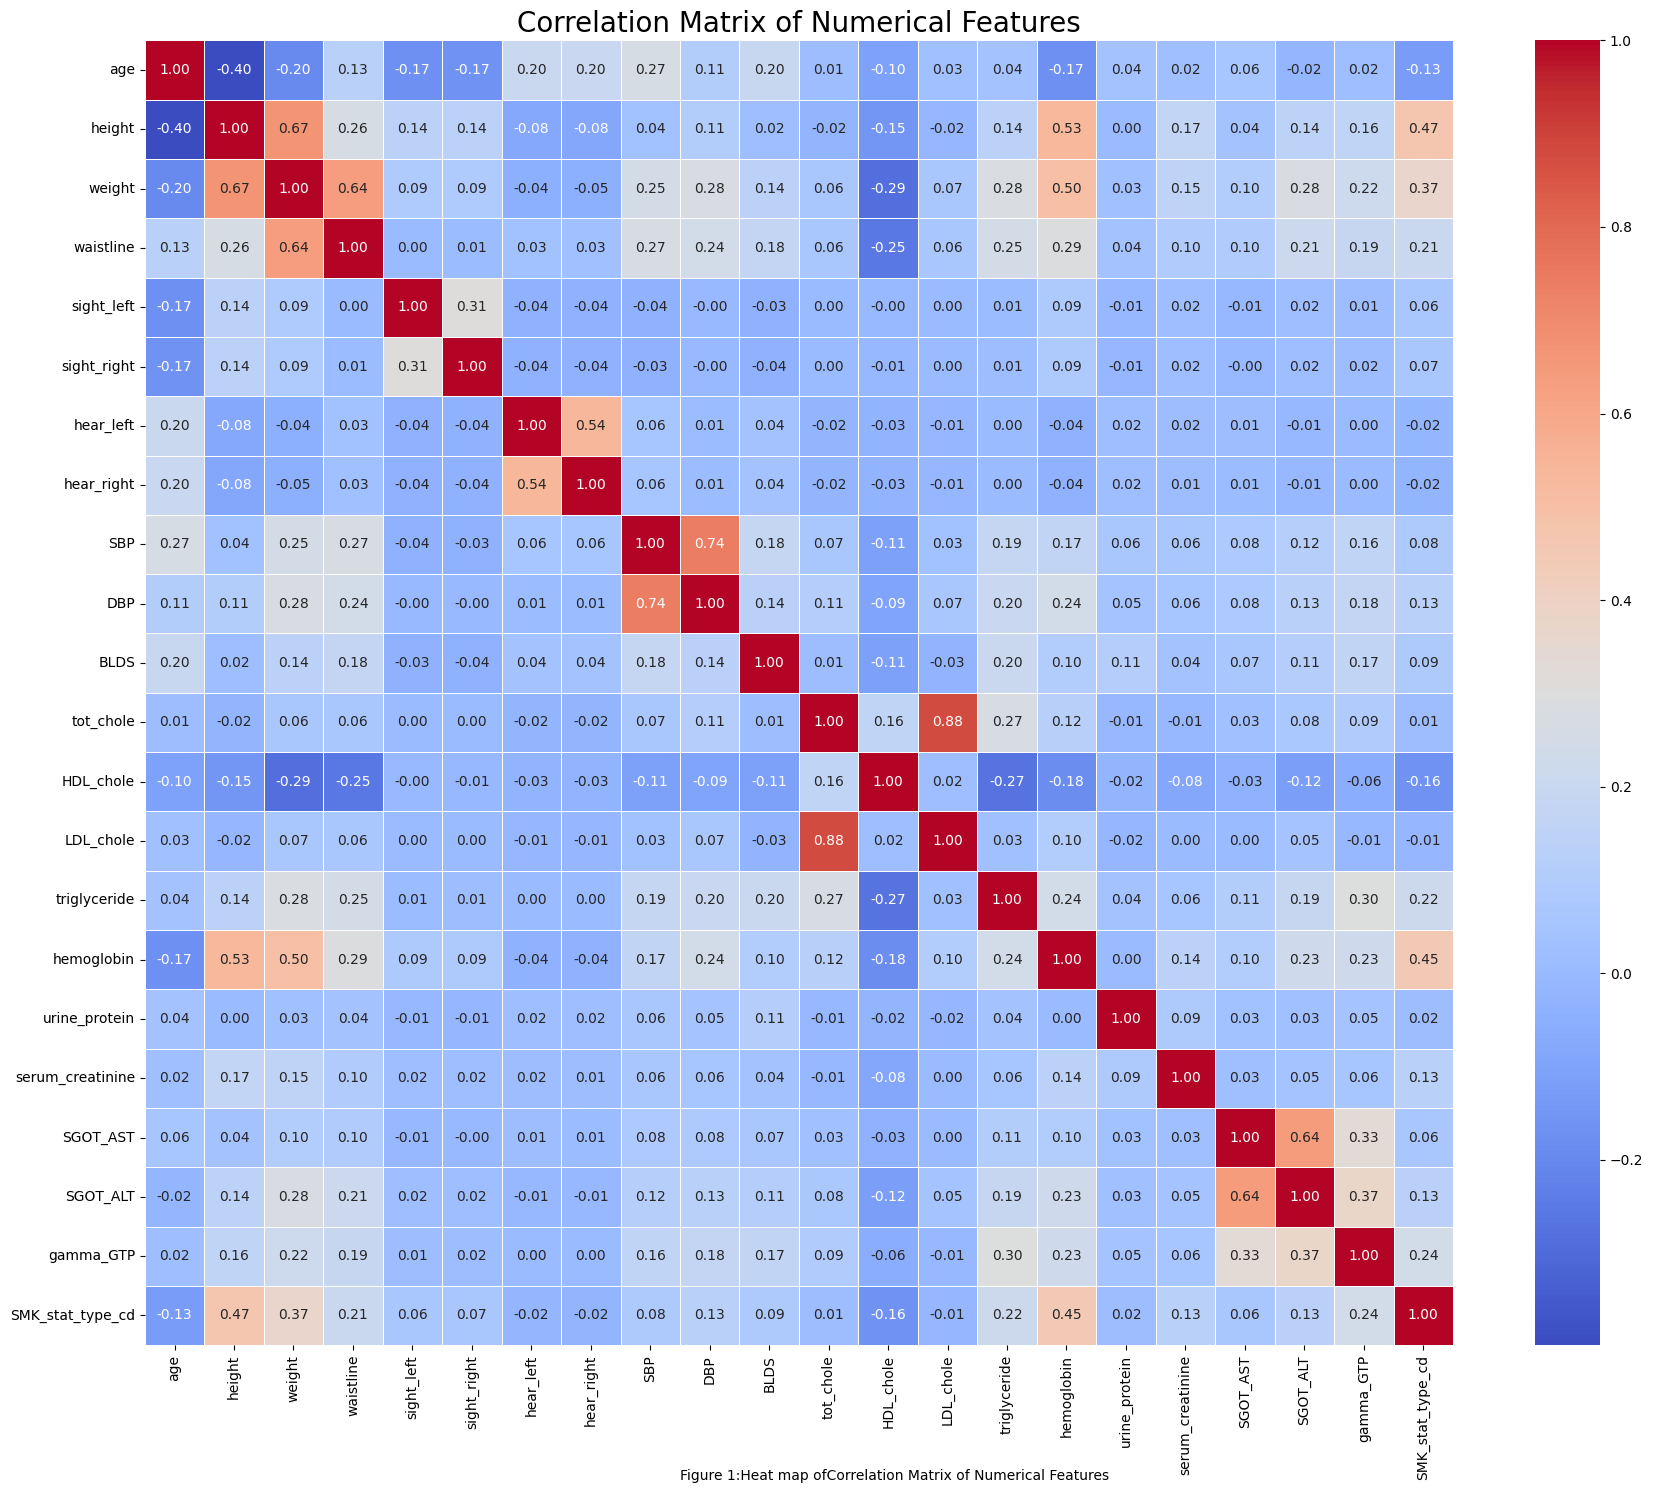

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical columns
correlation_matrix = X_processed[numerical_cols_X].corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 15))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()


plt.figtext(0.5, 0.01, 'Figure 1:Heat map ofCorrelation Matrix of Numerical Features', wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figuresclassification/figure1.png', dpi=300)
plt.show()

## Visualizing Numerical Feature Distributions



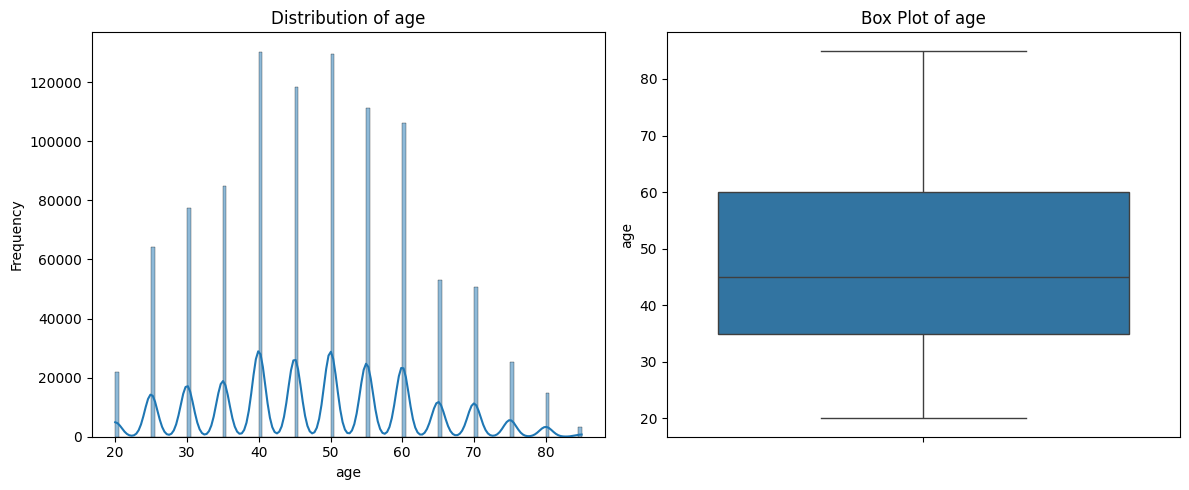

<Figure size 640x480 with 0 Axes>

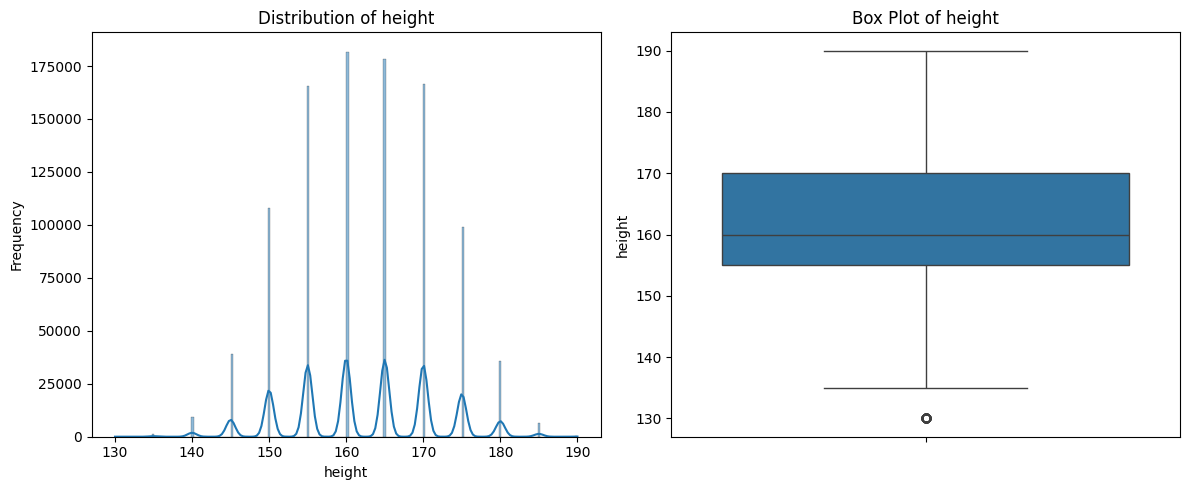

<Figure size 640x480 with 0 Axes>

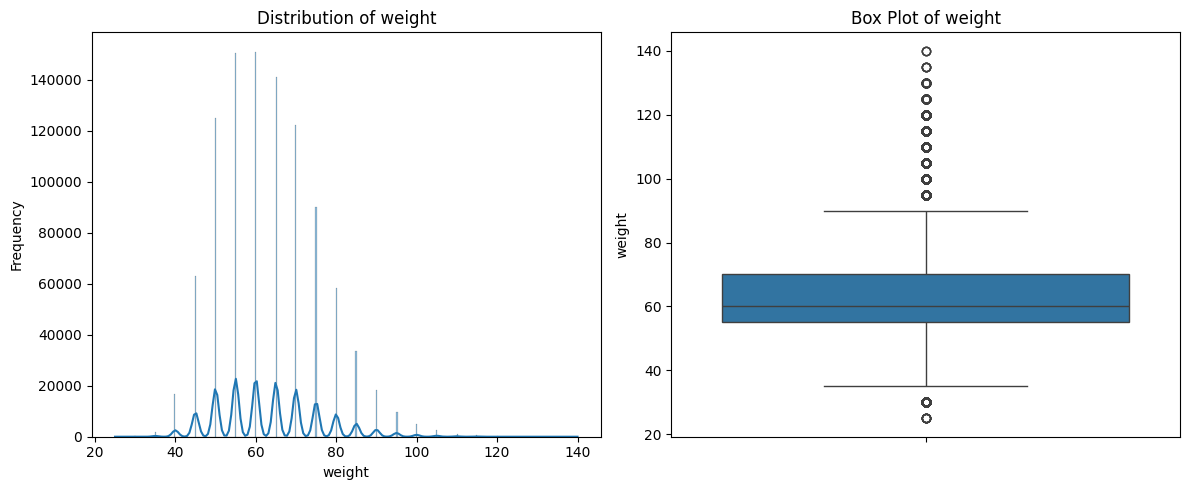

<Figure size 640x480 with 0 Axes>

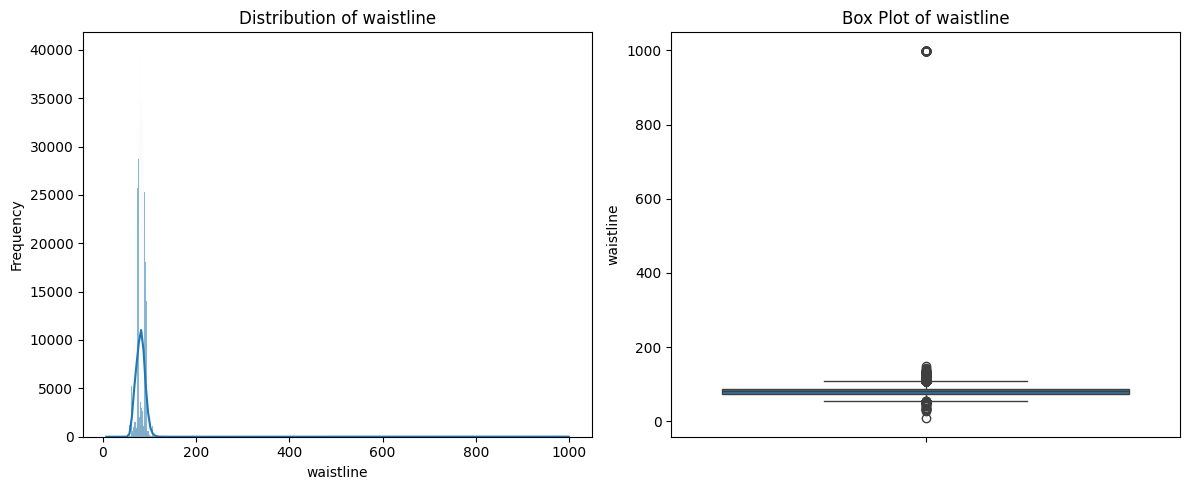

<Figure size 640x480 with 0 Axes>

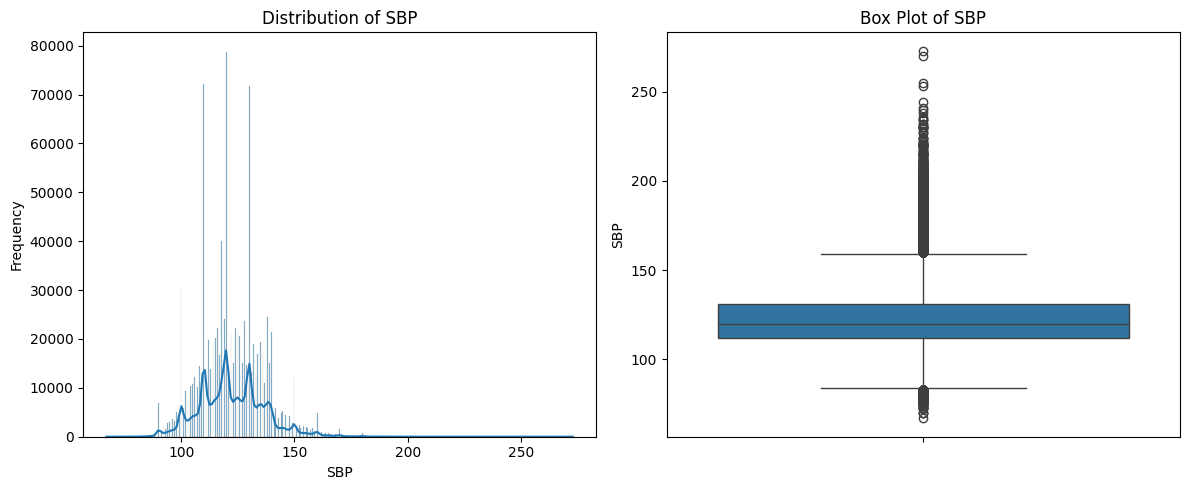

<Figure size 640x480 with 0 Axes>

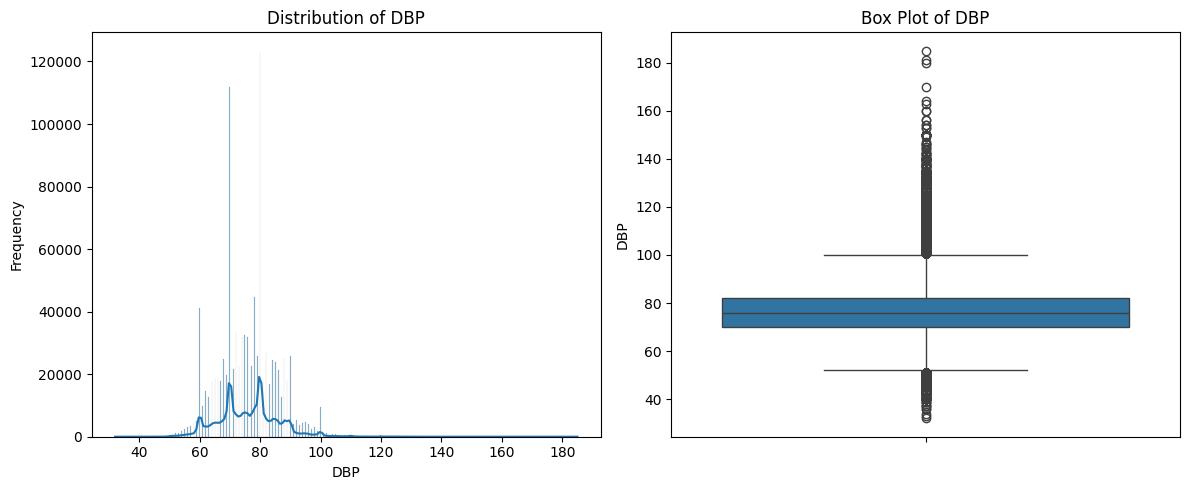

<Figure size 640x480 with 0 Axes>

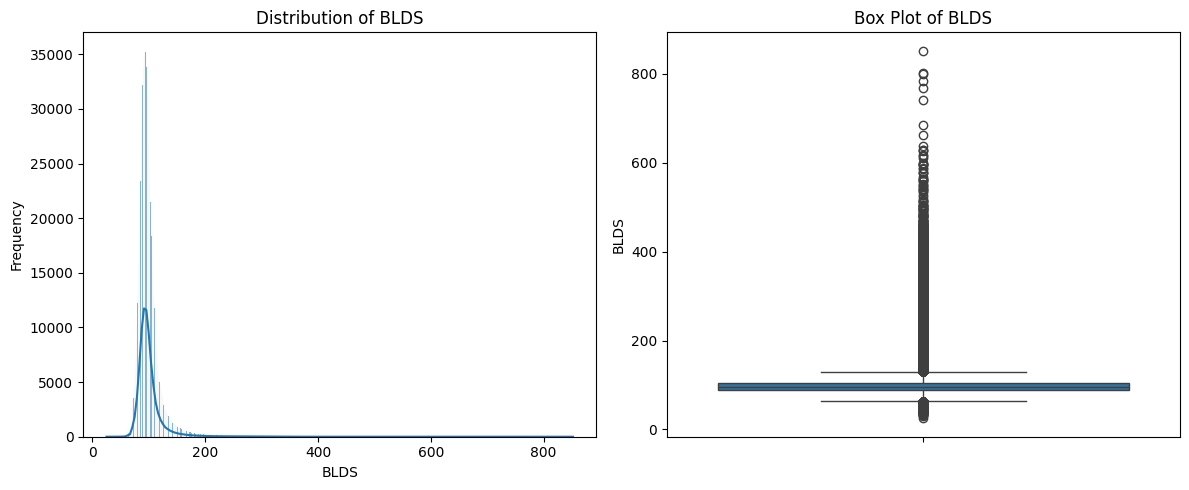

<Figure size 640x480 with 0 Axes>

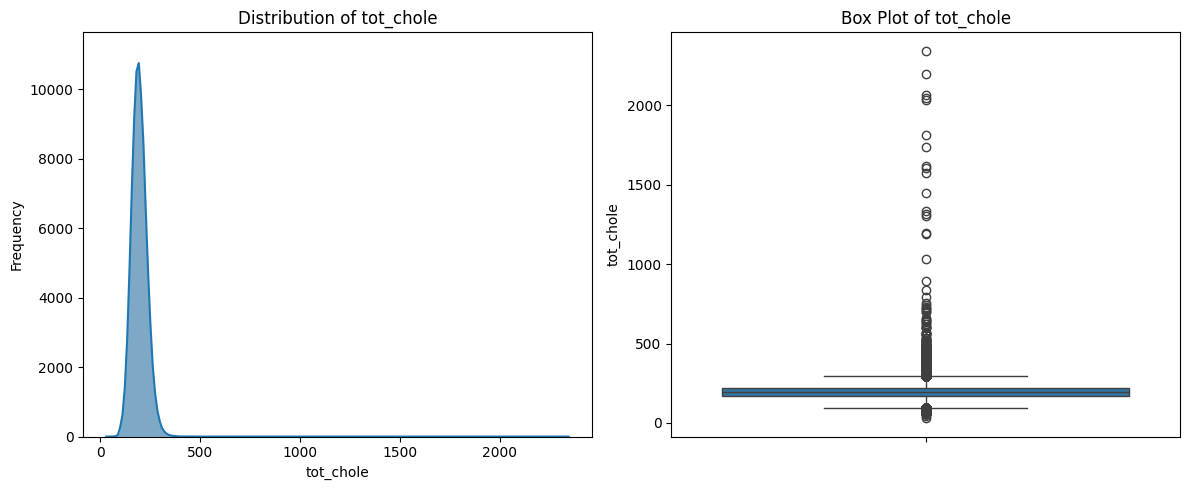

<Figure size 640x480 with 0 Axes>

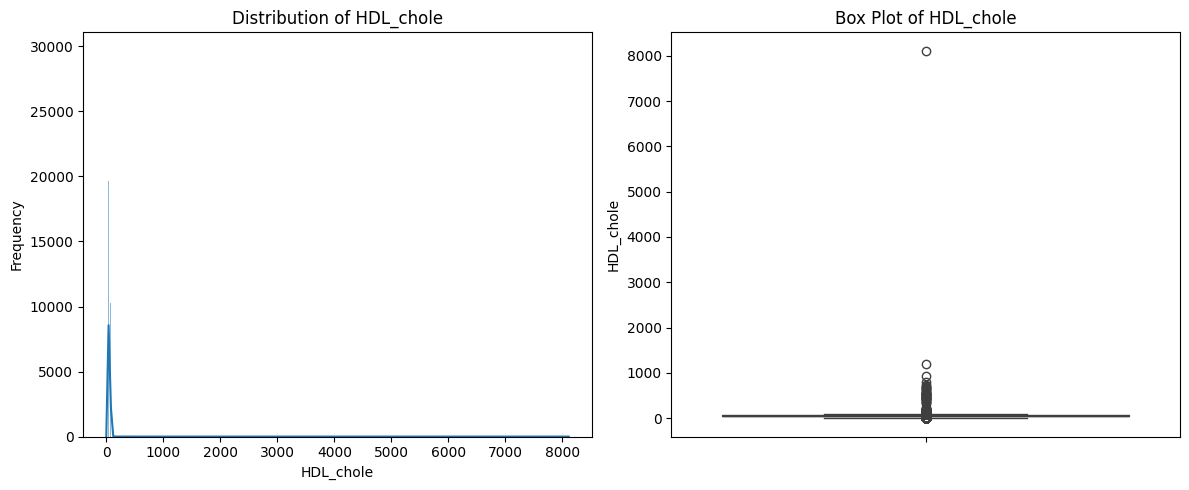

<Figure size 640x480 with 0 Axes>

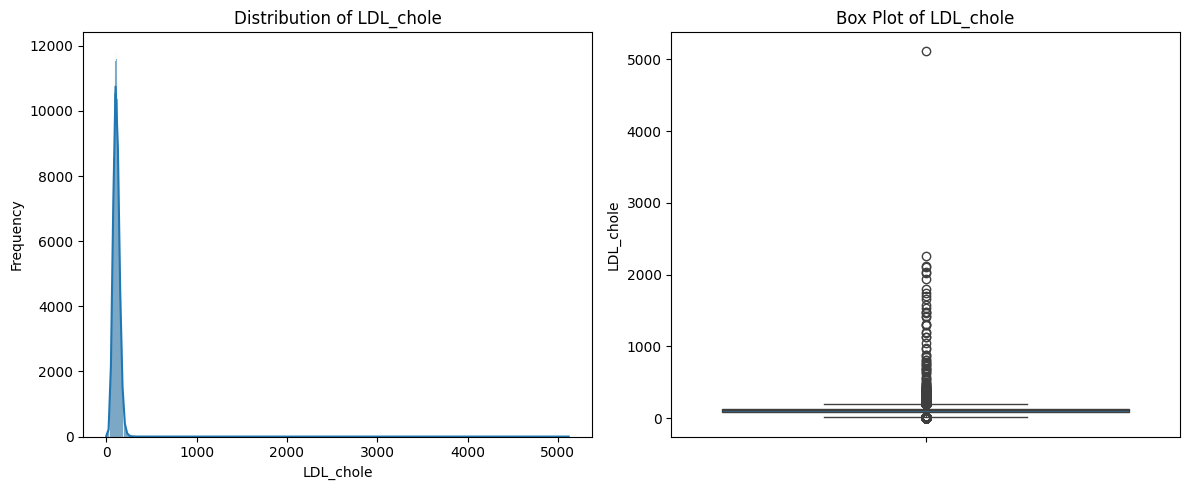

<Figure size 640x480 with 0 Axes>

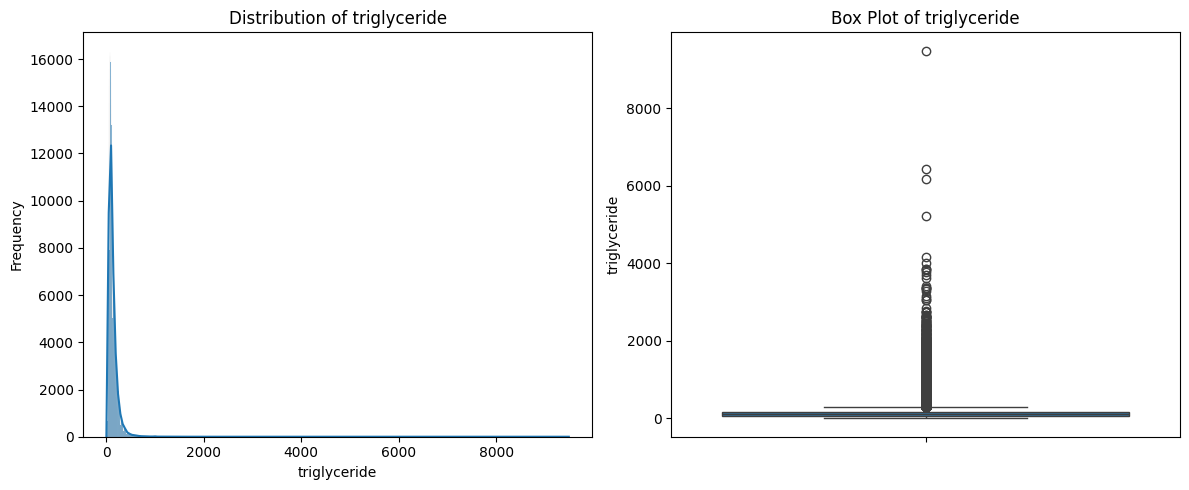

<Figure size 640x480 with 0 Axes>

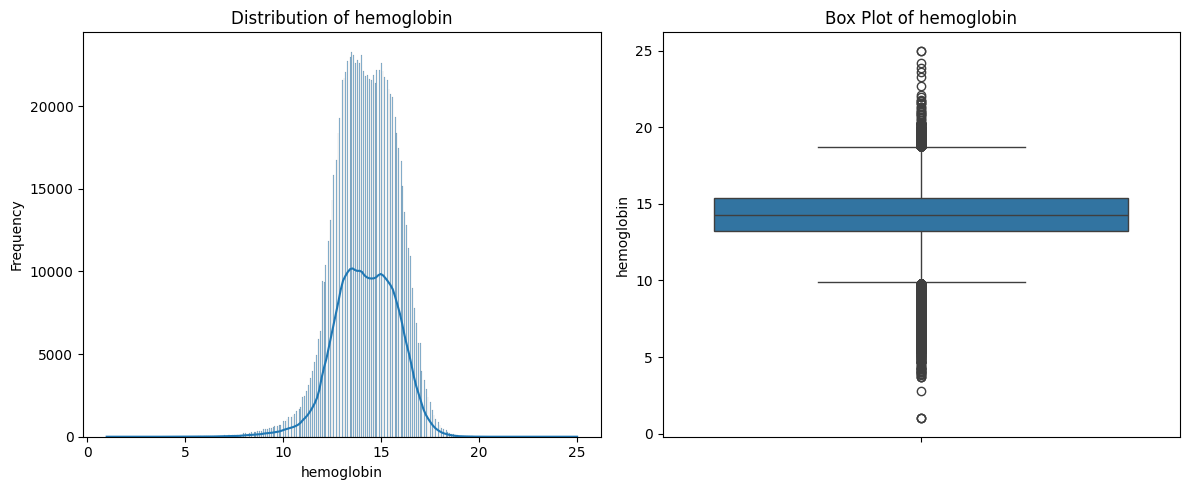

<Figure size 640x480 with 0 Axes>

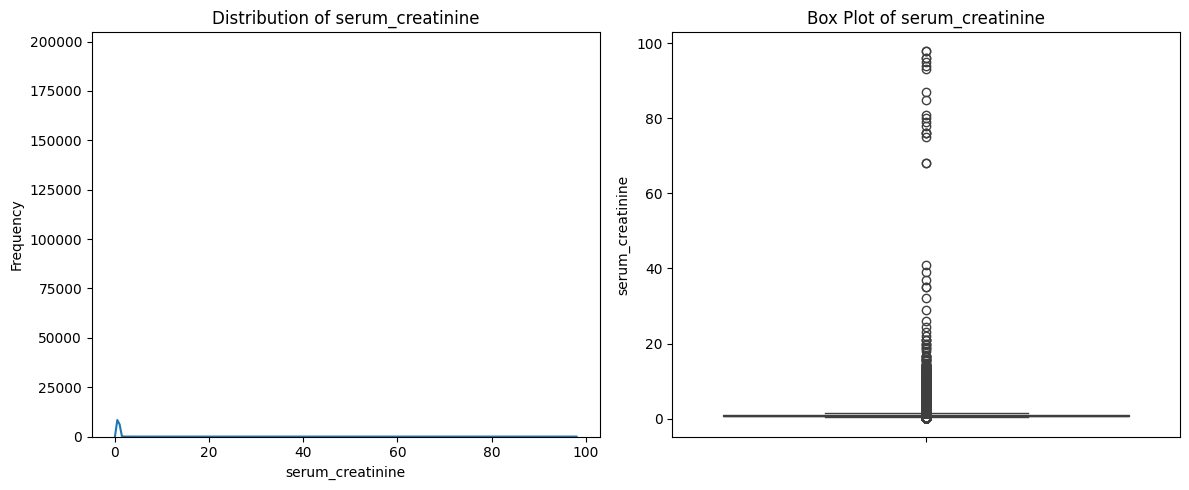

<Figure size 640x480 with 0 Axes>

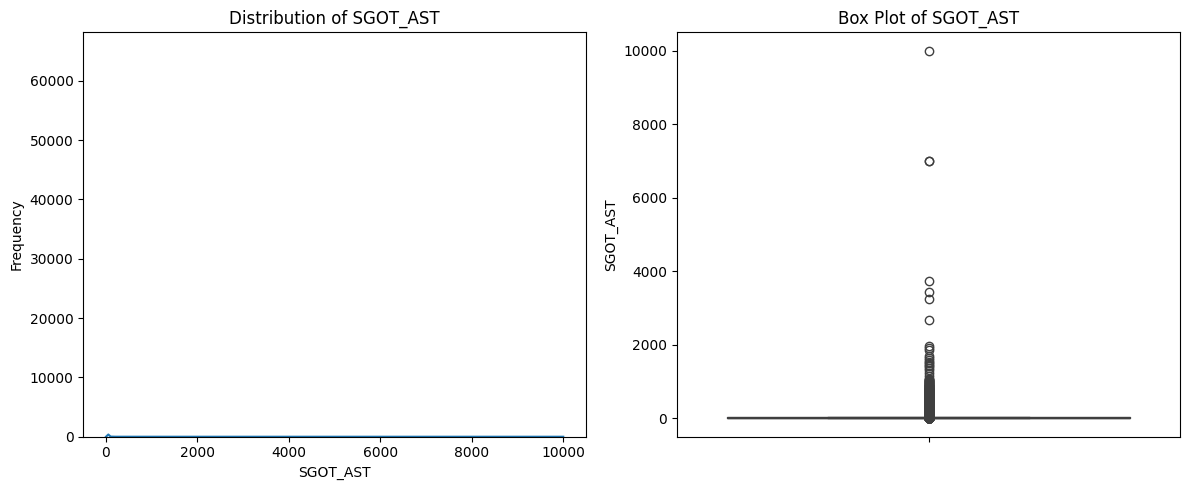

<Figure size 640x480 with 0 Axes>

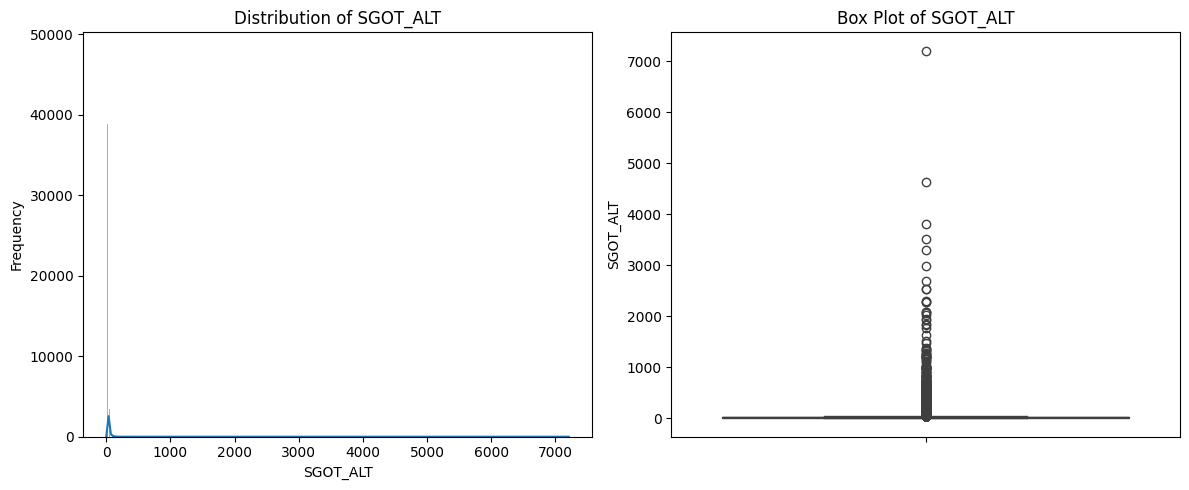

<Figure size 640x480 with 0 Axes>

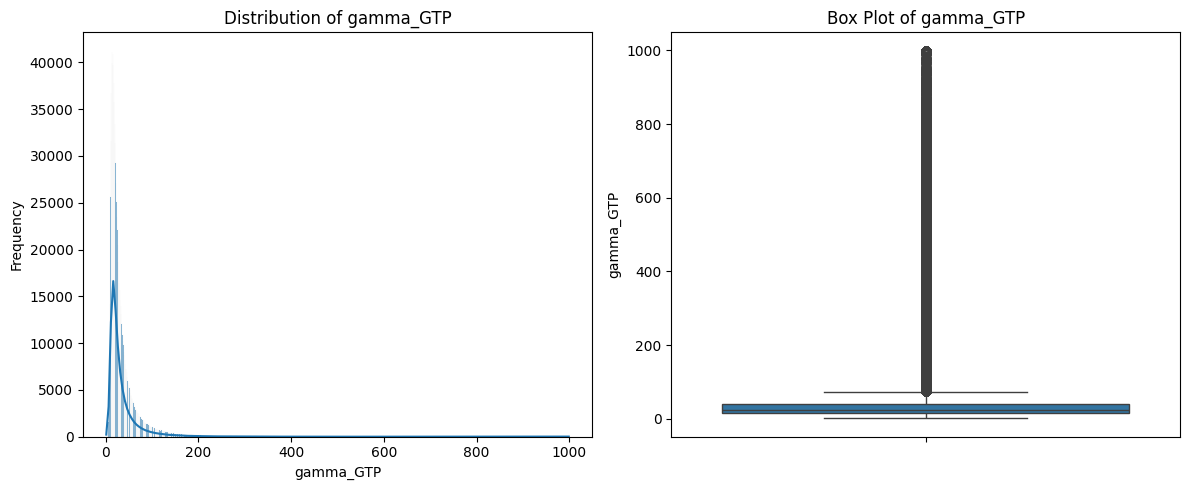

<Figure size 640x480 with 0 Axes>

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['age', 'height', 'weight', 'waistline', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP']

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Box plot
    sns.boxplot(y=df[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Box Plot of {col}')
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

    # Add figure name and save the figure
    figure_name = f'Figure_Distribution_{col}.png'
    plt.figtext(0.5, 0.01, f'Figure 2 : Distribution and Box Plot of numerical colums', wrap=True, horizontalalignment='center', fontsize=10)
    plt.savefig(f'/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figuresclassification/figure2.png', dpi=300)
    plt.close(fig) # Close the figure to free up memory

### Insights from Numerical Feature Visualizations

After generating histograms and box plots for the numerical features, we can observe the following:

**1. `age`:**
*   **Distribution:** The histogram shows a multi-modal distribution, with peaks around 40-45 and 55-60 years, suggesting distinct age groups within the dataset. It's generally right-skewed, indicating more younger to middle-aged individuals. The data extends up to 85, as noted in previous analysis.
*   **Outliers:** The box plot confirms a clean distribution with no extreme outliers, as the values are within expected human age ranges.

**2. `height` and `weight`:**
*   **Distribution:** Both `height` and `weight` appear to follow a relatively normal distribution, with slight skewness. The histograms are somewhat bell-shaped, centered around their means.
*   **Outliers:** The box plots show a few individual outliers at the lower and higher ends, but these are generally within plausible biological ranges for adults, especially after the initial outlier cleaning (e.g., minimum weight 25kg, maximum 140kg). The data is fairly concentrated around the mean.

**3. `waistline`:**
*   **Distribution:** The histogram for `waistline` is generally right-skewed, indicating that most individuals have lower waist circumferences, but there's a tail extending to higher values. There's a noticeable peak around the 80s.
*   **Outliers:** After cleaning, the box plot shows that the extreme 999.0 cm outlier has been removed. However, there are still some values that appear as outliers in the upper range, which might represent individuals with higher waist measurements, potentially indicating obesity or related conditions. These are now within the defined biological upper bound of 150cm.

**4. Blood Pressure (`SBP`, `DBP`):**
*   **Distribution:** Both `SBP` and `DBP` show distributions that are roughly bell-shaped but with a notable right skew, meaning a larger number of individuals have values towards the lower end of the blood pressure spectrum, with fewer individuals having very high blood pressure.
*   **Outliers:** The box plots for both `SBP` and `DBP` indicate the presence of outliers, particularly at the higher end, even after initial cleaning. These might represent individuals with hypertension, and while they are 'outliers' statistically, they can be clinically significant and not necessarily data errors.

**5. Cholesterol Levels (`tot_chole`, `HDL_chole`, `LDL_chole`, `triglyceride`):**
*   **Distribution:** These features generally show right-skewed distributions. While the bulk of the data is concentrated at lower to mid-ranges, there are tails extending to higher values, indicating individuals with elevated cholesterol or triglyceride levels.
*   **Outliers:** Despite the initial cleaning to remove extreme implausible values, the box plots still show a considerable number of individual outliers at the higher end for all these cholesterol-related metrics. These values, though still high, are now within biologically plausible (albeit unhealthy) ranges, suggesting these are real observations of individuals with hyperlipidemia. For example, `triglyceride` still shows a significant spread of upper outliers, which is common for this measure.

**6. Liver Enzymes (`SGOT_AST`, `SGOT_ALT`, `gamma_GTP`):**
*   **Distribution:** All three liver enzyme levels exhibit strong right-skewed distributions. A large proportion of the population has low (normal) levels, with a long tail indicating individuals with elevated enzyme levels.
*   **Outliers:** The box plots clearly show numerous outliers at the higher end for these features, even after setting generous upper bounds. These elevated levels are clinically relevant and could point to liver damage or other health issues. While statistically 'outliers', they are likely valid data points within biological reality.

**Overall Observations:**
*   The initial outlier cleaning successfully removed biologically implausible extreme values, making the data more reliable.
*   Many features, especially health indicators like blood pressure, cholesterol, and liver enzymes, still show right-skewed distributions and numerous upper-end outliers. These are likely real, clinically significant observations rather than data entry errors. This skewness suggests that typical statistical analyses assuming normal distributions might not be appropriate, and transformations or robust methods may be needed for modeling.
*   The visualizations confirm that the data is now better prepared for further analysis, but the nature of the distributions and remaining outliers highlight important characteristics of the population's health.

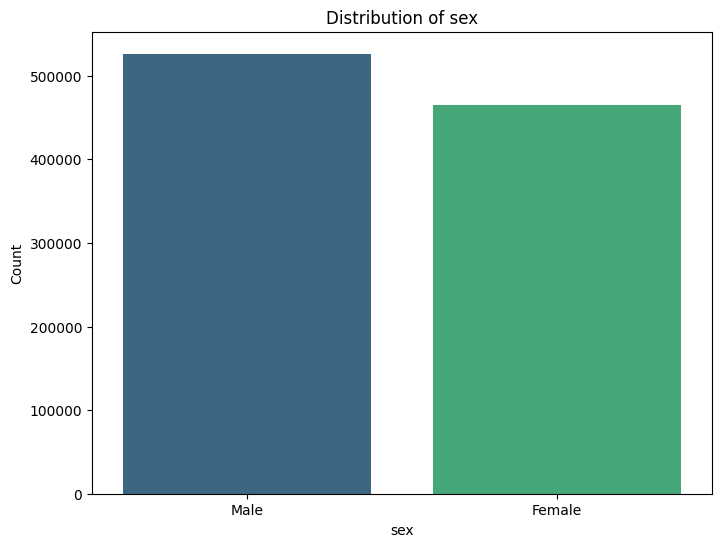

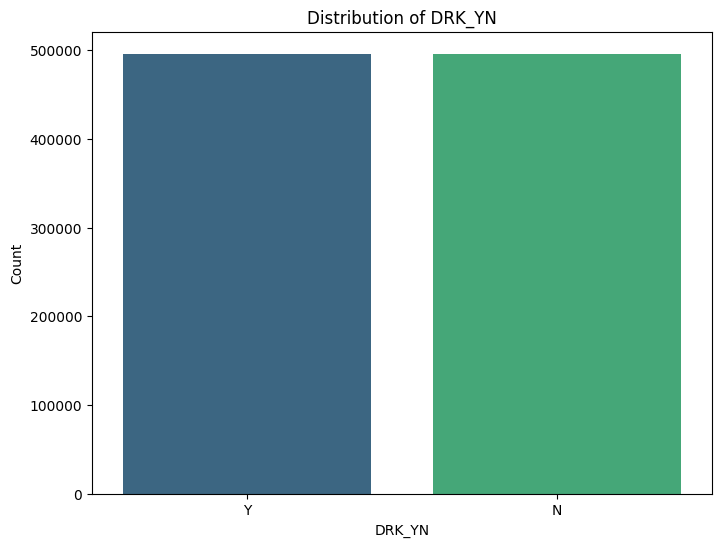

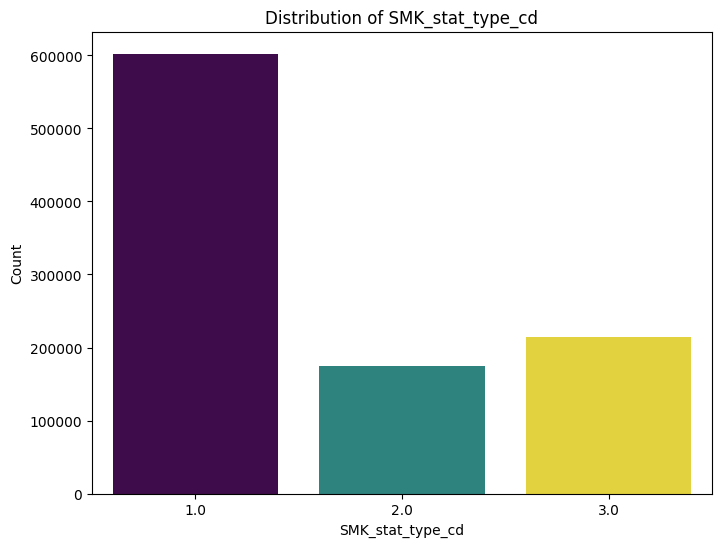

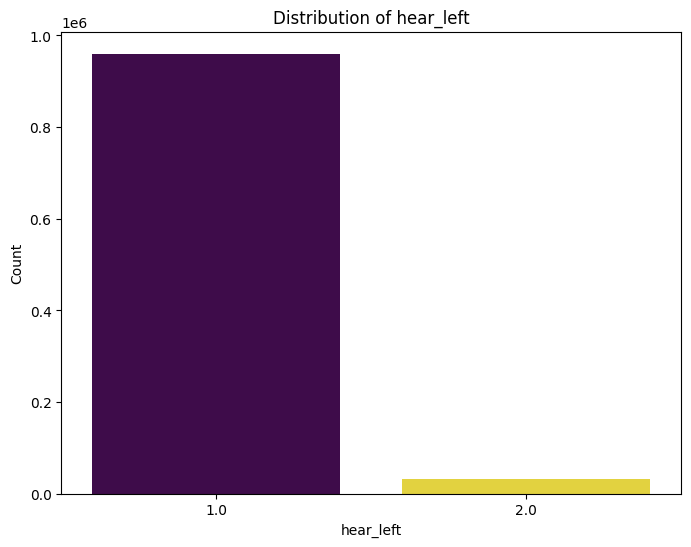

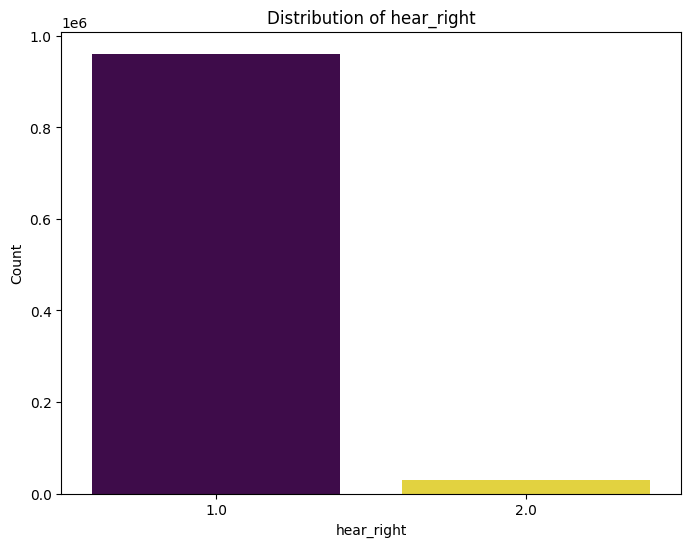

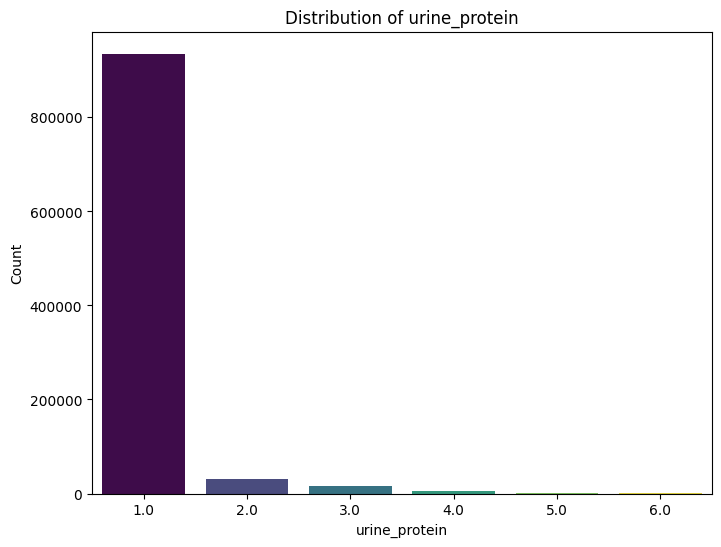

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['sex', 'DRK_YN', 'SMK_stat_type_cd', 'hear_left', 'hear_right', 'urine_protein']

for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

    # Add figure name and save the figure
    figure_name = f'Figure_Distribution_{col}.png'
    plt.figtext(0.5, 0.01, f'Figure 3 : Distribution of sex, DRK_YN, SMK_stat_type_cd, hear_left, hear_right, urine_protein', wrap=True, horizontalalignment='center', fontsize=10)
    plt.savefig(f'/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figuresclassification/FIGURE3', dpi=300)
    plt.close() # Close the figure to free up memory

Insights from Categorical Feature Visualizations

Count plots of categorical features reveal the following patterns:

Sex:
The dataset is reasonably balanced by sex, with approximately 53.1% male and 46.9% female participants, indicating adequate representation of both groups.

Drinking Status (DRK_YN):
Drinking status is nearly perfectly balanced, with roughly equal proportions of drinkers and non-drinkers. This makes DRK_YN well-suited for use as a binary target variable without concerns of class imbalance.

Smoking Status (SMK_stat_type_cd):
Non-smokers form the majority (~60.8%), followed by current smokers (~21.6%) and past smokers (~17.6%). This reflects a moderate class imbalance, which would require consideration if smoking status were used as a prediction target.

Hearing Status (hear_left, hear_right):
Both variables are highly imbalanced, with most individuals classified as having normal hearing and only a small minority showing impairment. This is typical of health screening data but poses challenges for predictive modeling.

Urine Protein (urine_protein):
The vast majority of individuals fall into the normal category, with higher protein levels being rare. This results in a strongly imbalanced distribution, similar to the hearing variables.

Overall:
While sex and DRK_YN are well balanced, SMK_stat_type_cd shows moderate imbalance, and hear_left, hear_right, and urine_protein are highly skewed toward normal categories. These distributional characteristics are important considerations for downstream modeling and evaluation.

## Exploring Relationships between Features and Target Variables


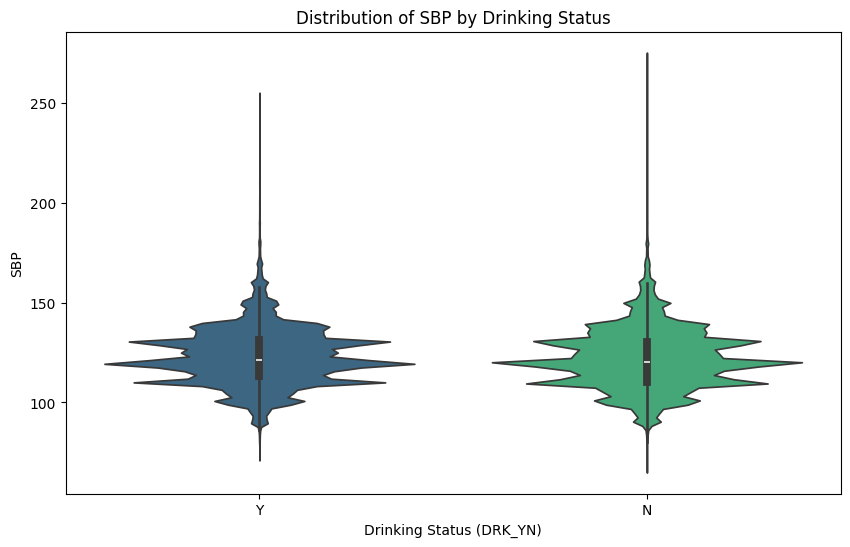

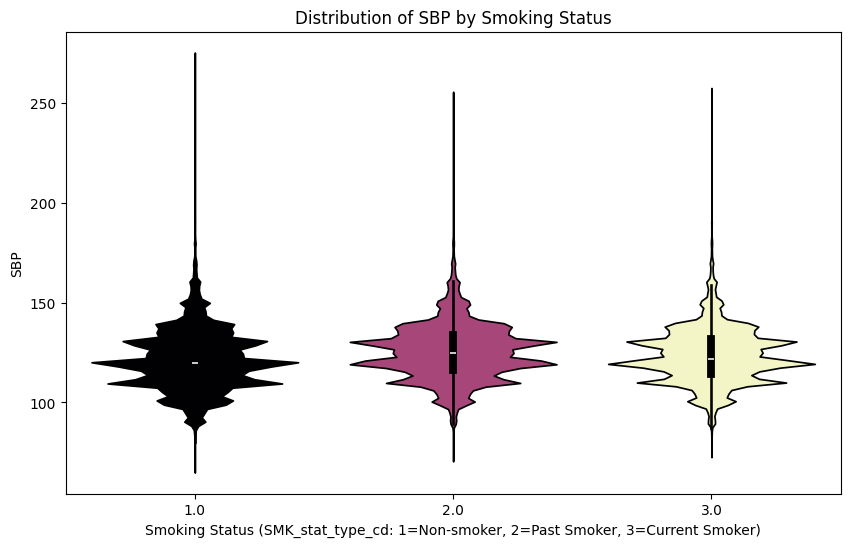

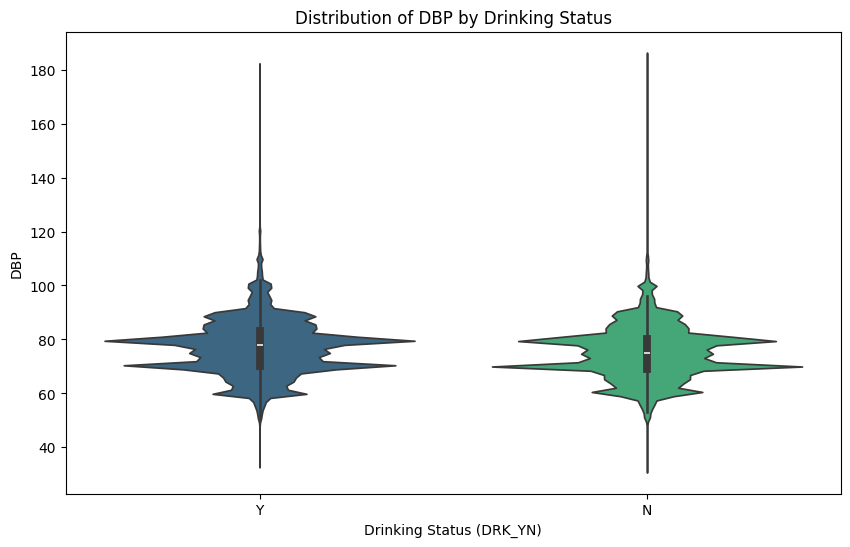

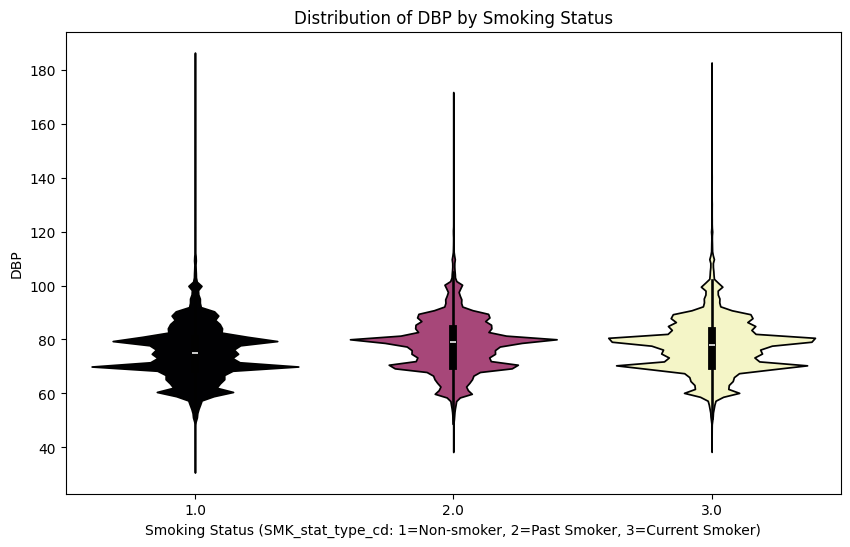

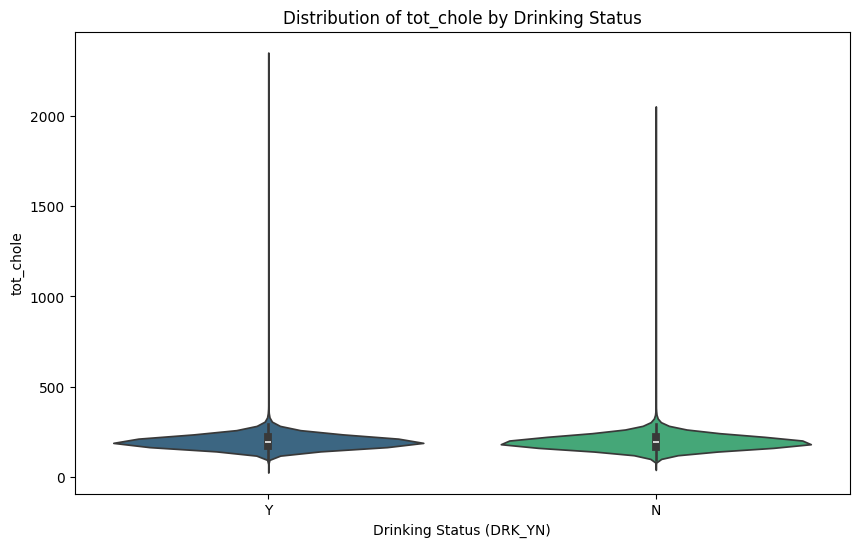

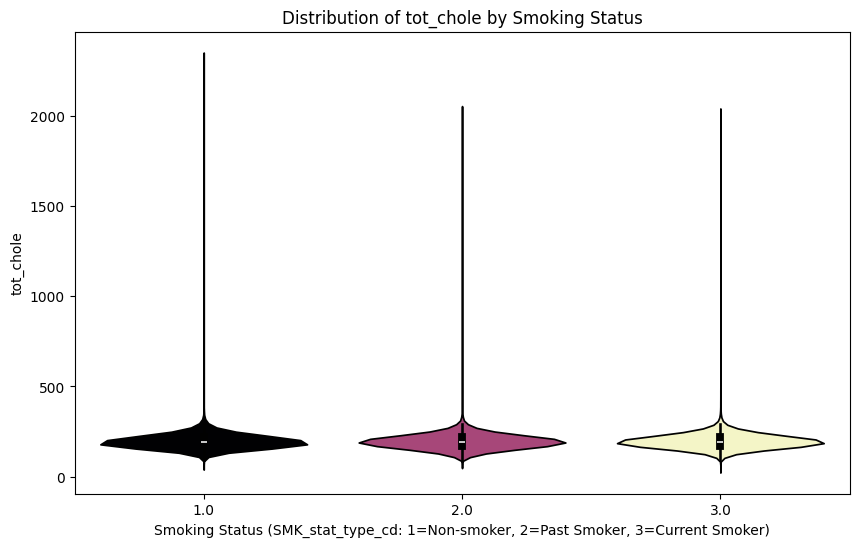

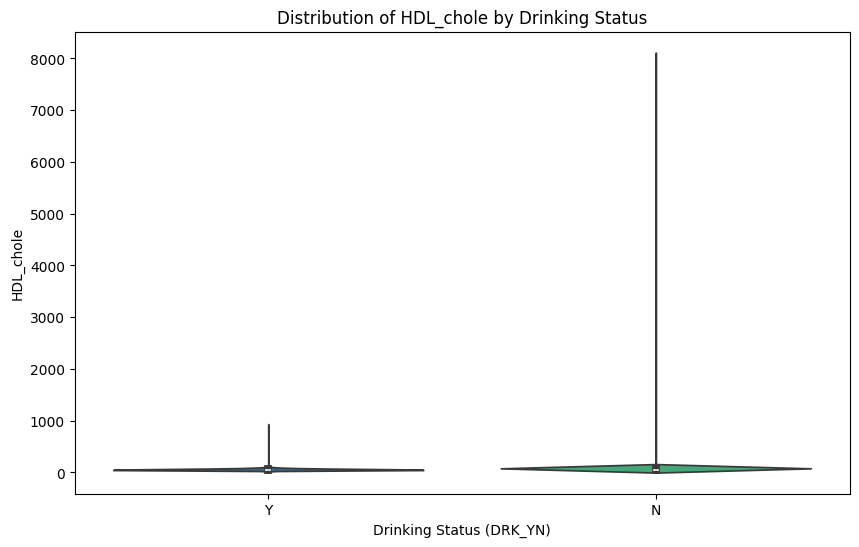

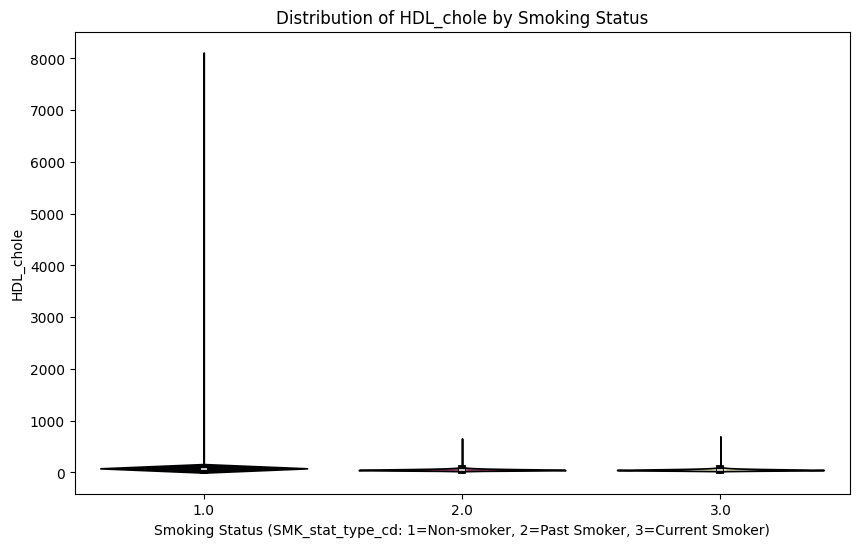

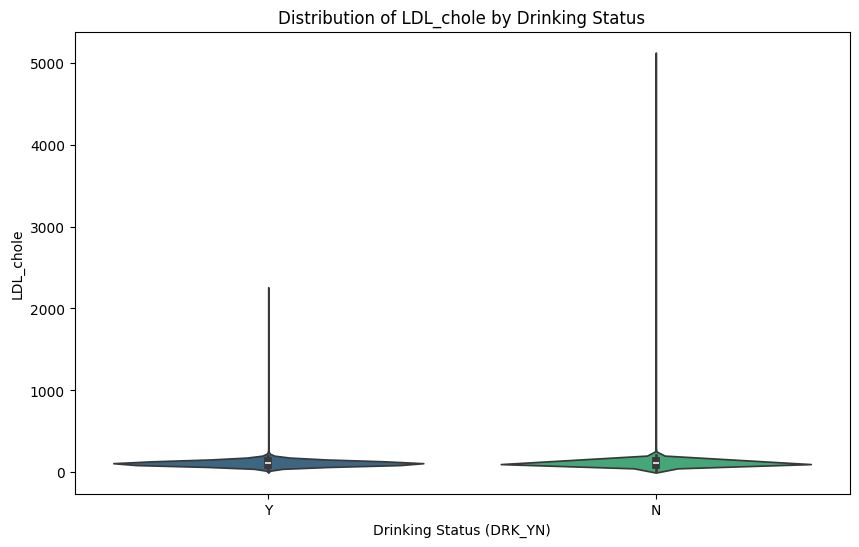

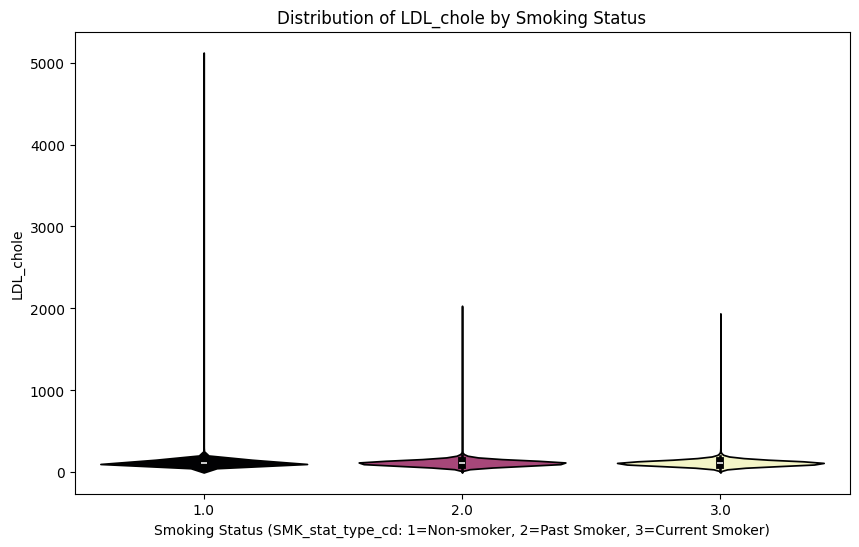

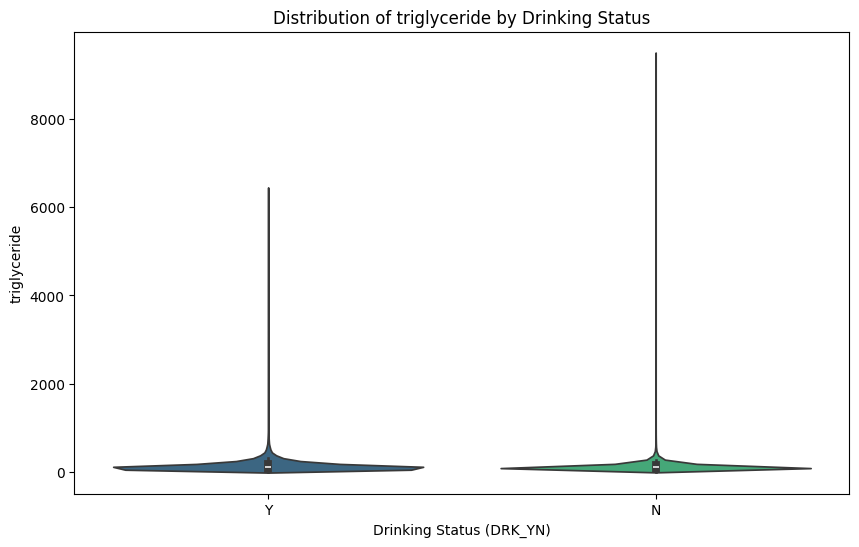

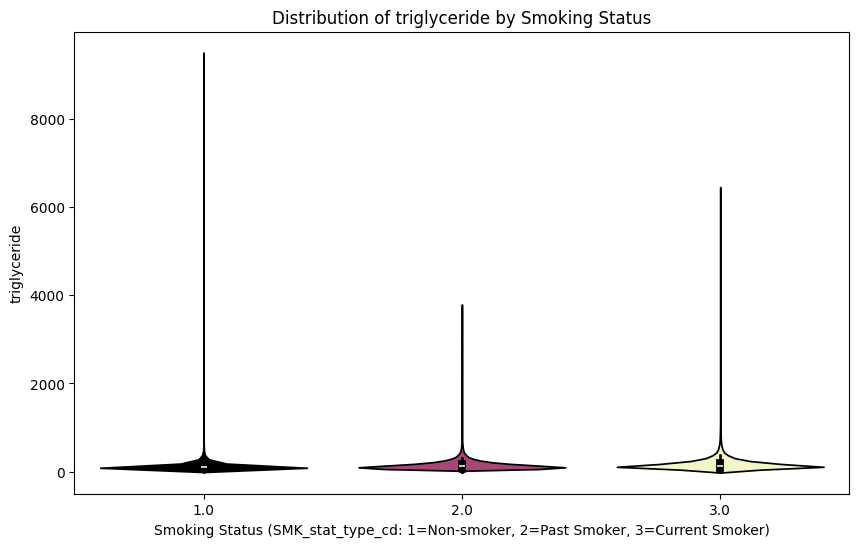

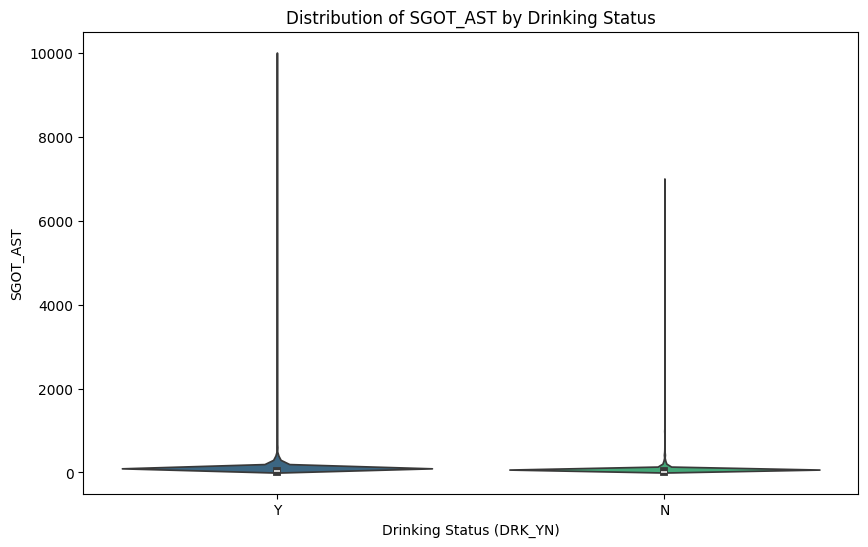

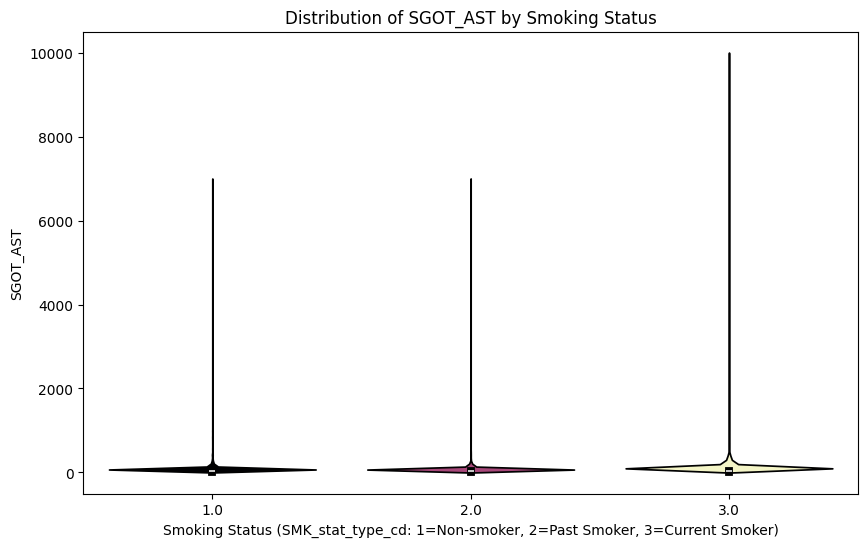

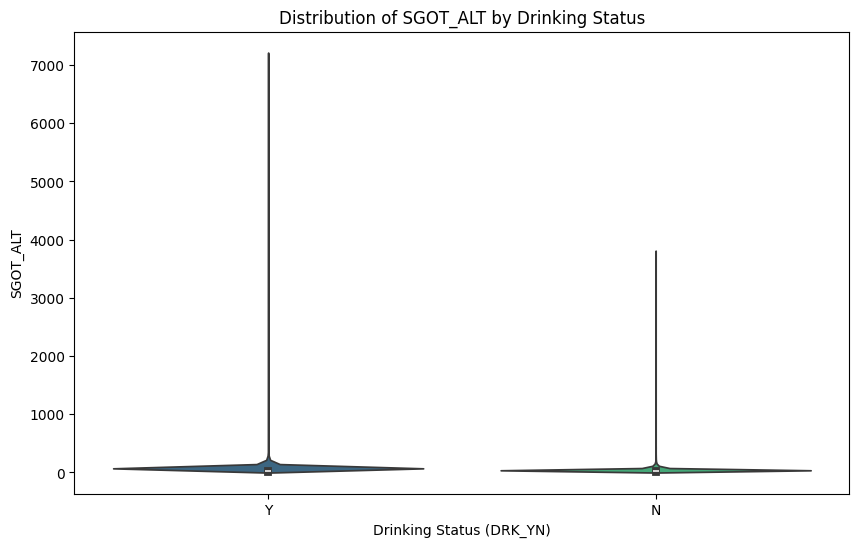

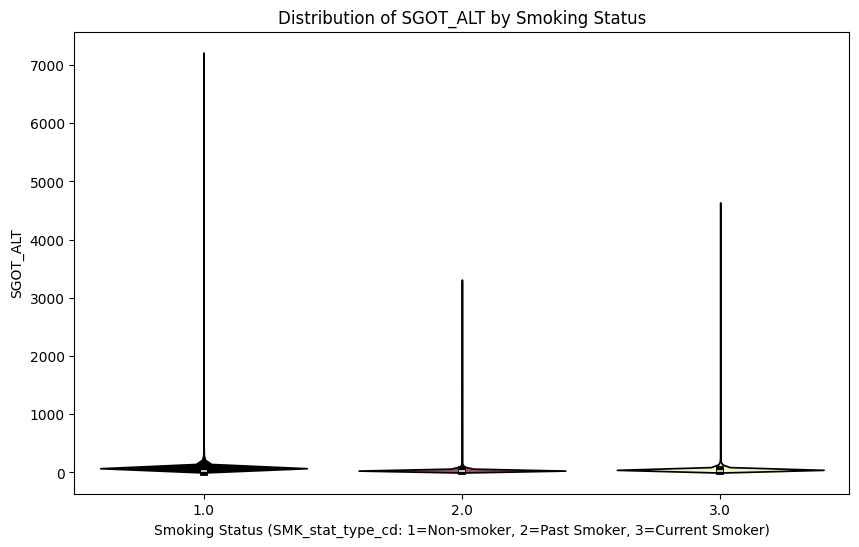

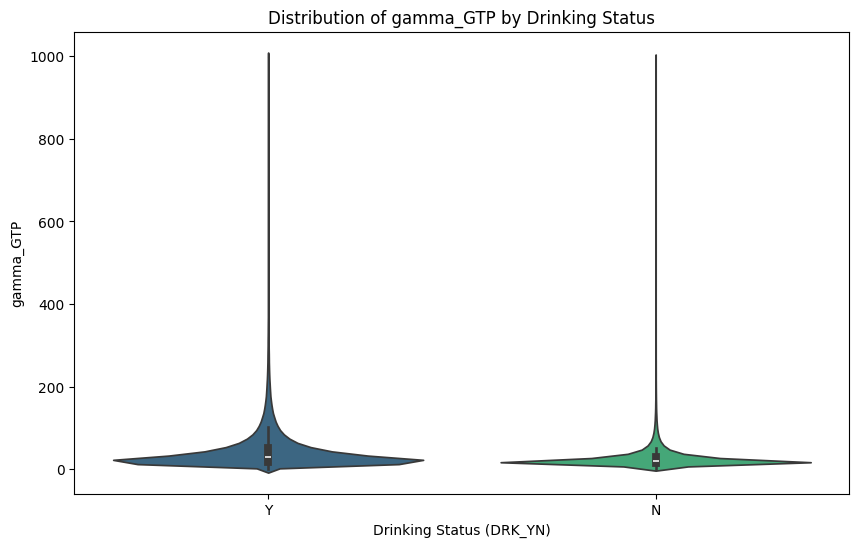

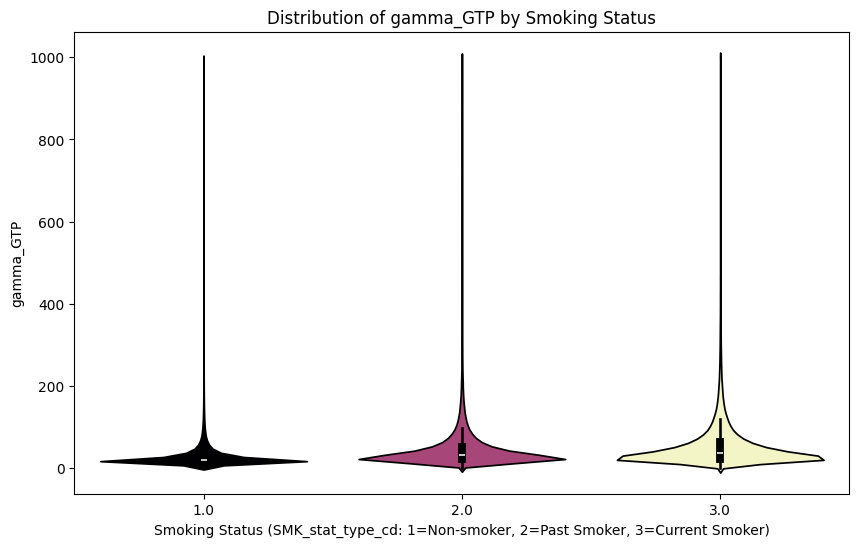

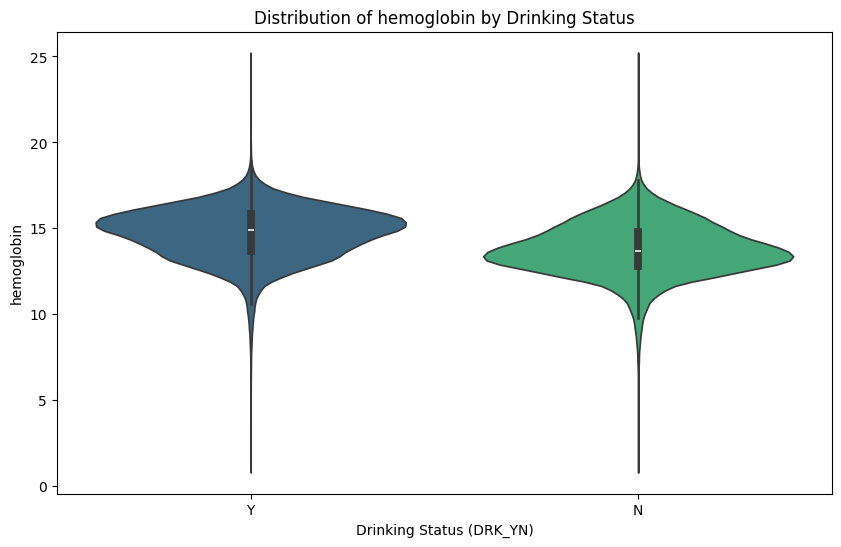

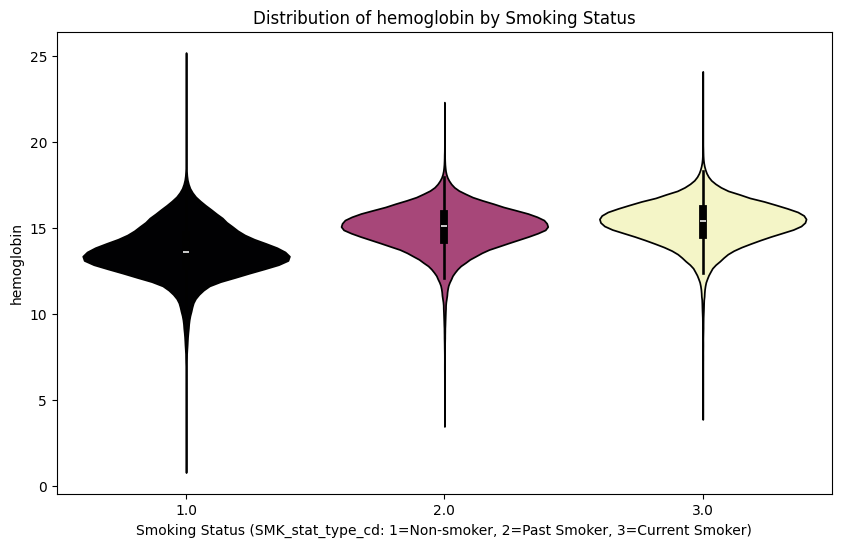

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

health_indicators = ['SBP', 'DBP', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP', 'hemoglobin']

for col in health_indicators:
    # Plot against DRK_YN
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x='DRK_YN', y=col, hue='DRK_YN', palette='viridis', legend=False)
    plt.title(f'Distribution of {col} by Drinking Status')
    plt.xlabel('Drinking Status (DRK_YN)')
    plt.ylabel(col)
    plt.show()

    # Plot against SMK_stat_type_cd
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x='SMK_stat_type_cd', y=col, hue='SMK_stat_type_cd', palette='magma', legend=False)
    plt.title(f'Distribution of {col} by Smoking Status')
    plt.xlabel('Smoking Status (SMK_stat_type_cd: 1=Non-smoker, 2=Past Smoker, 3=Current Smoker)')
    plt.ylabel(col)
    plt.show()

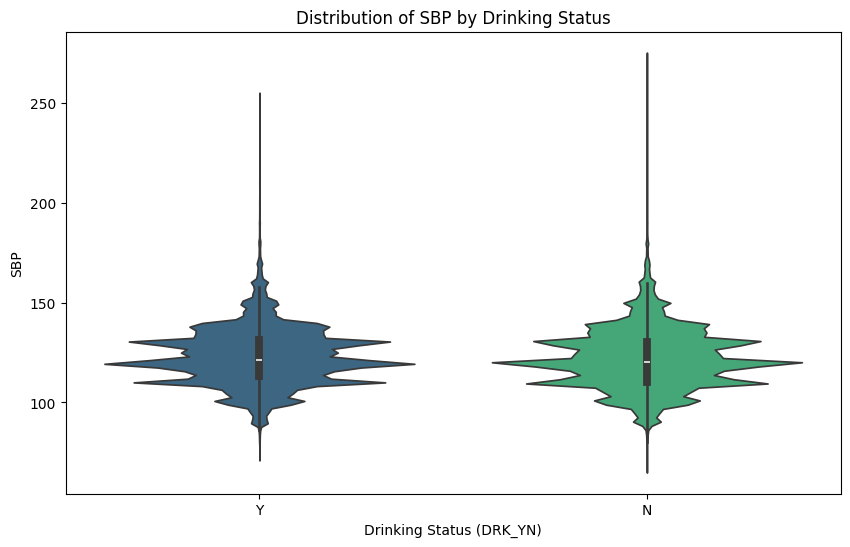

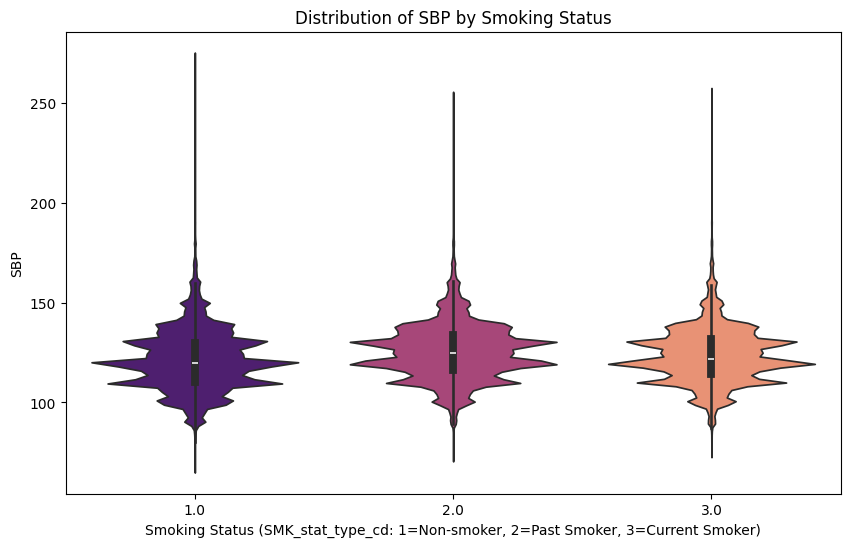

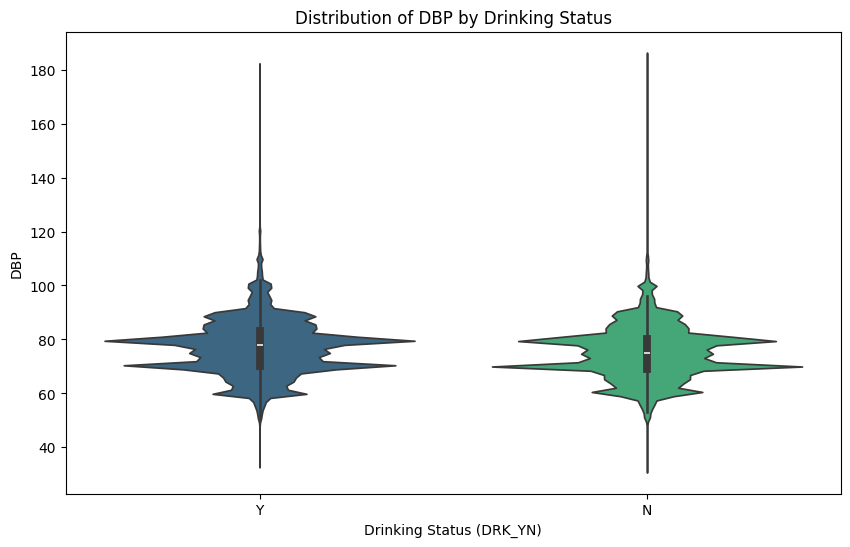

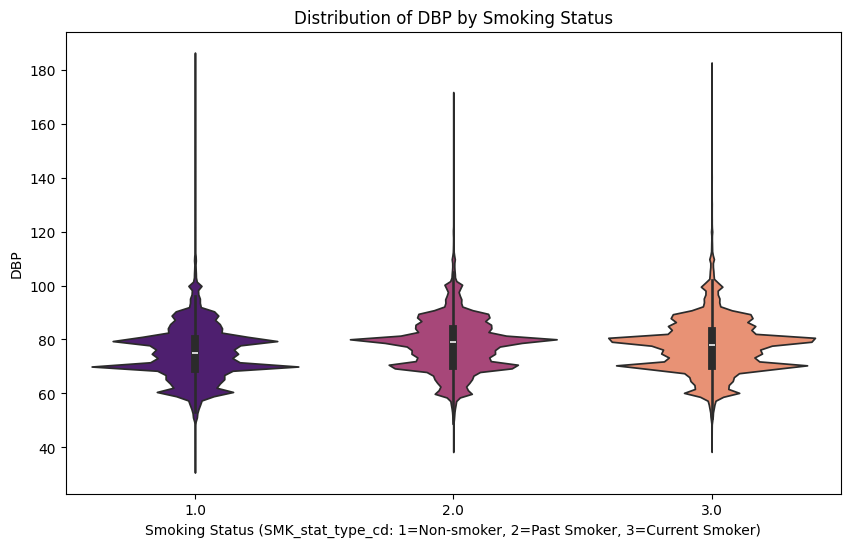

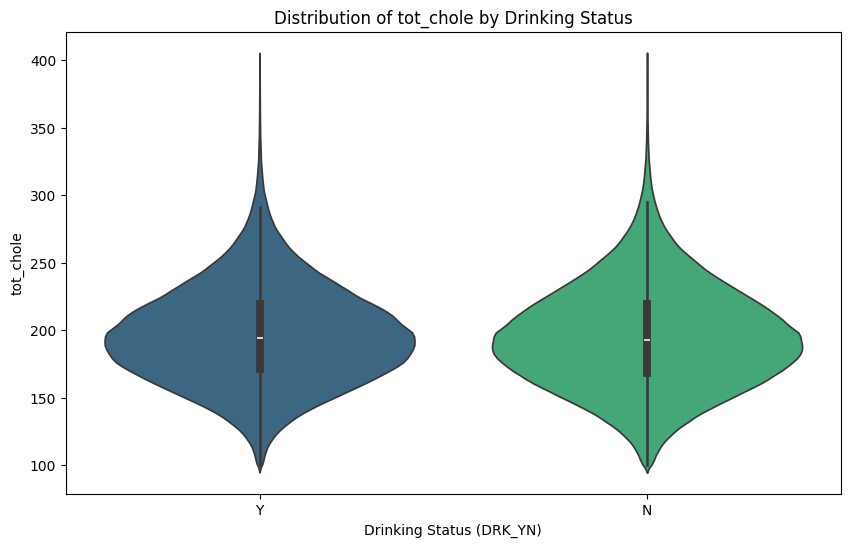

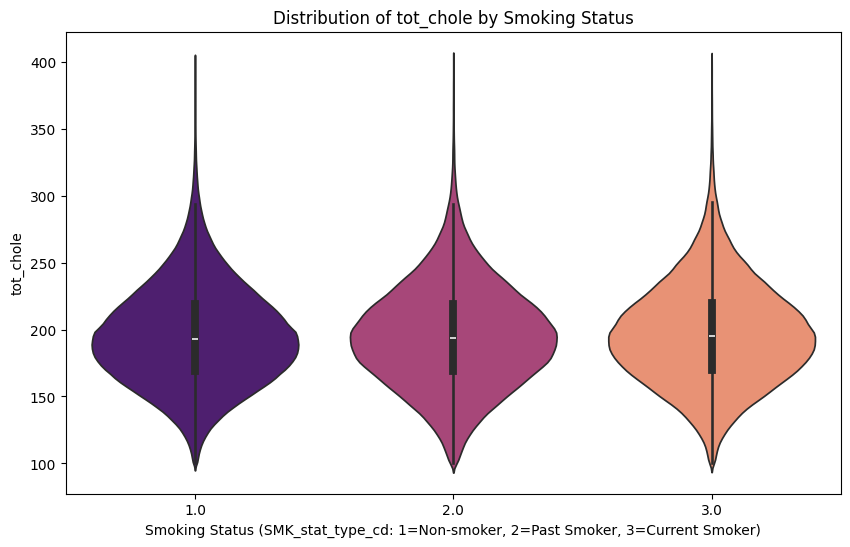

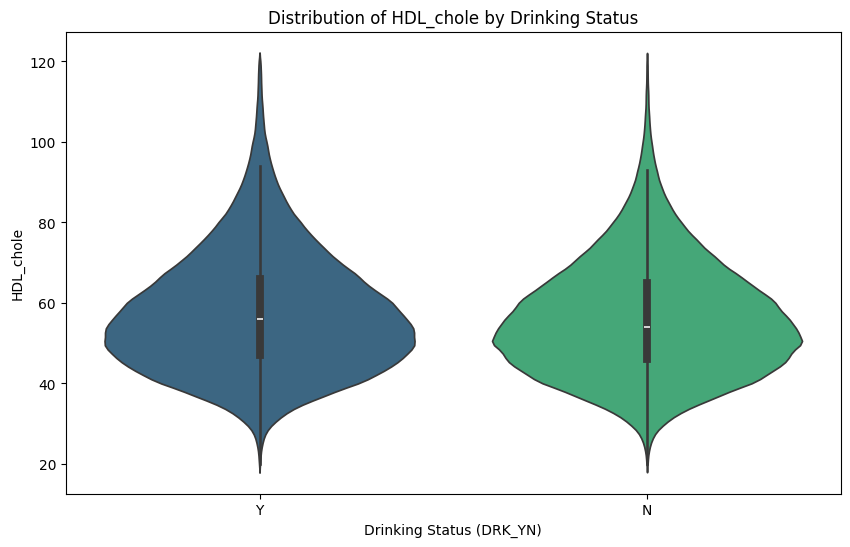

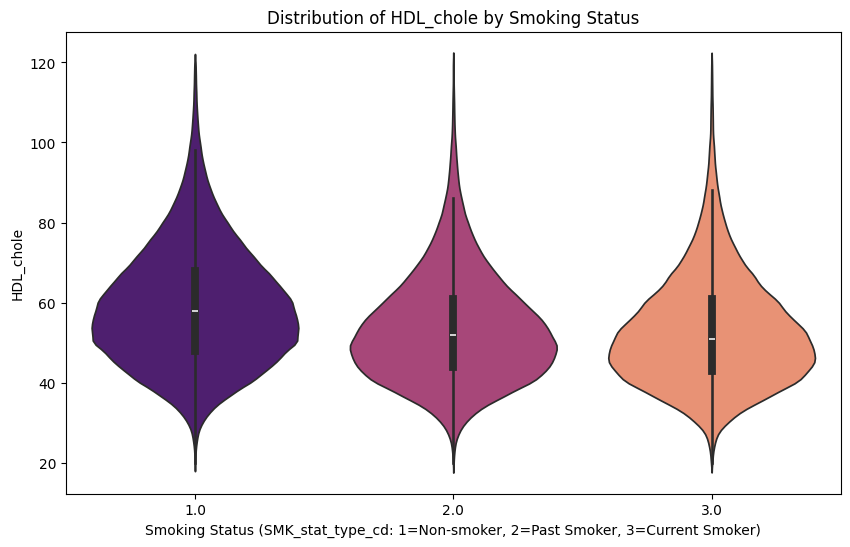

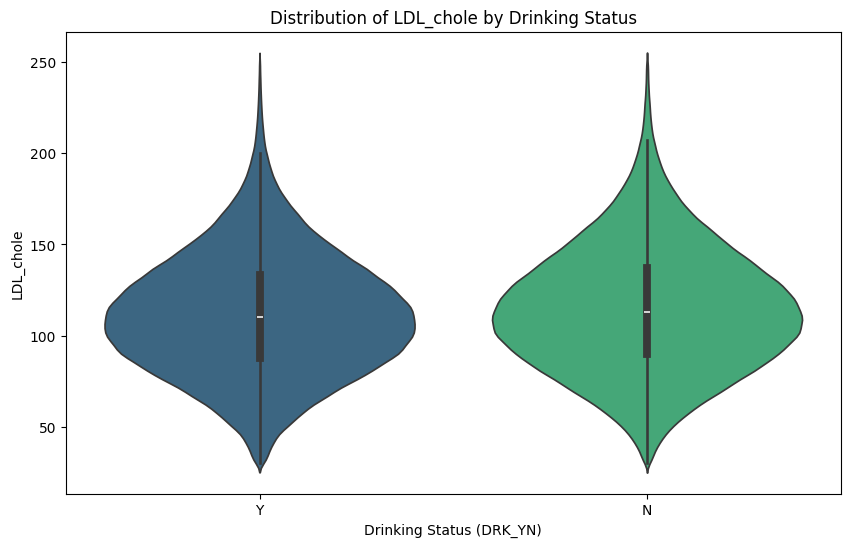

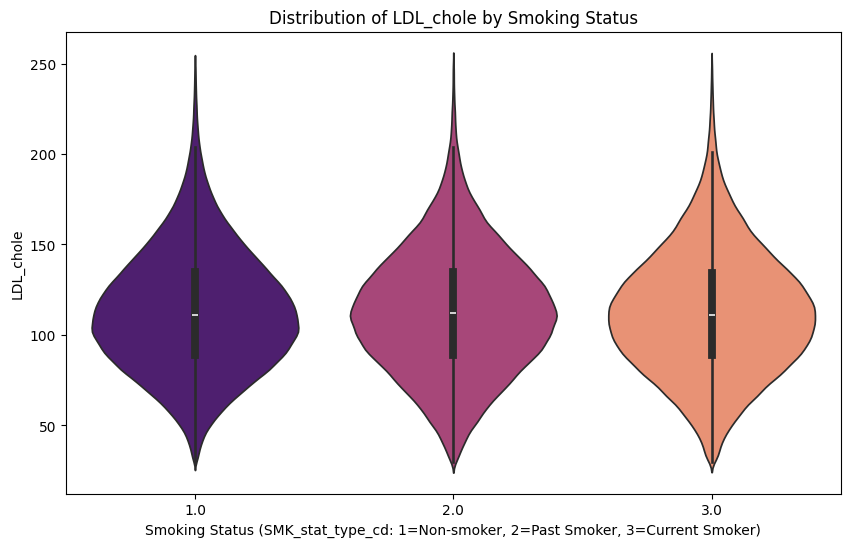

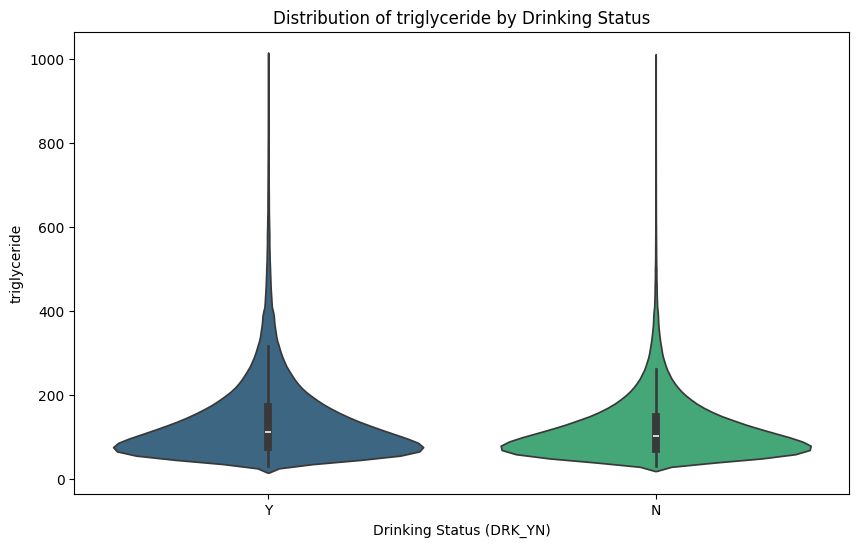

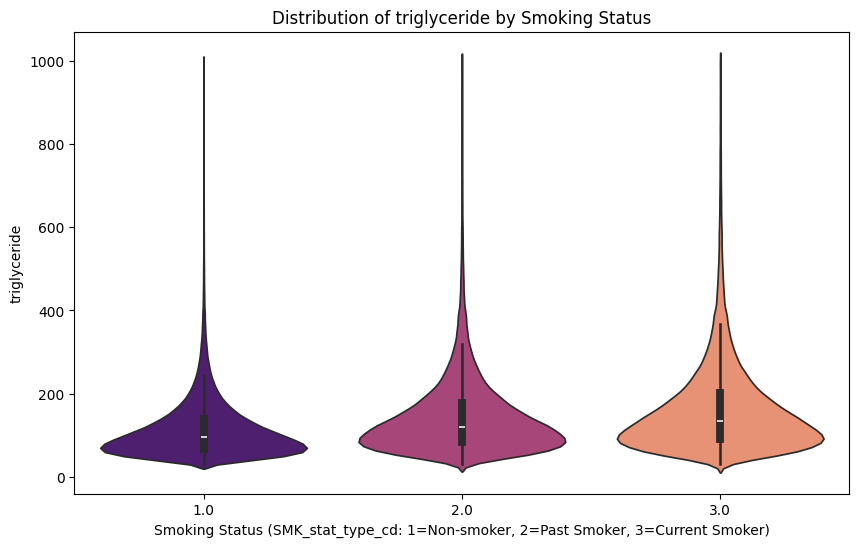

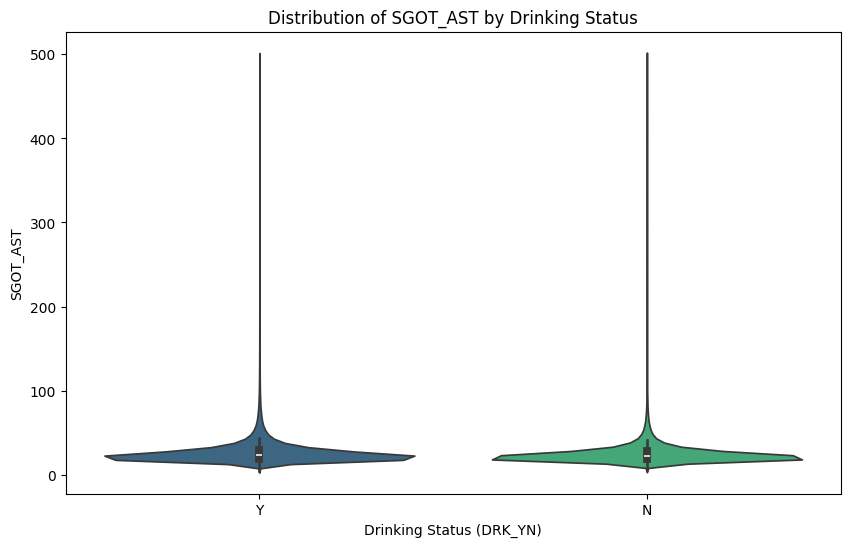

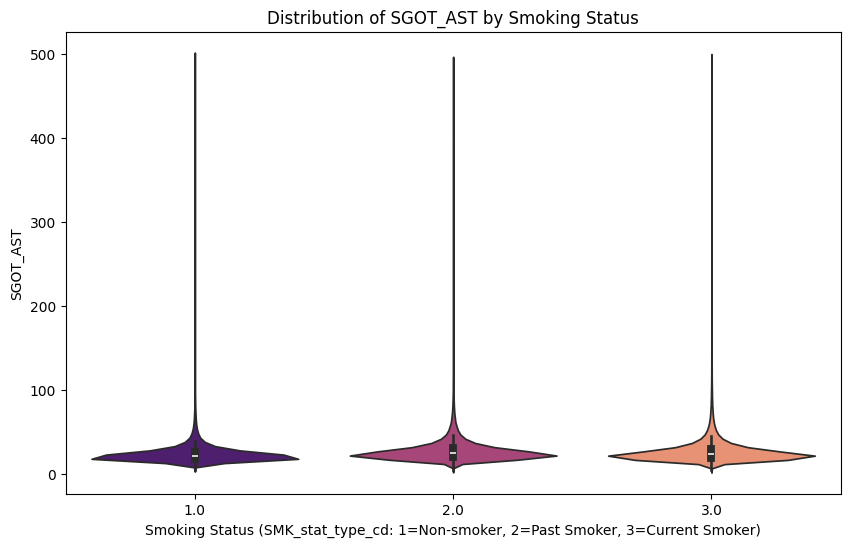

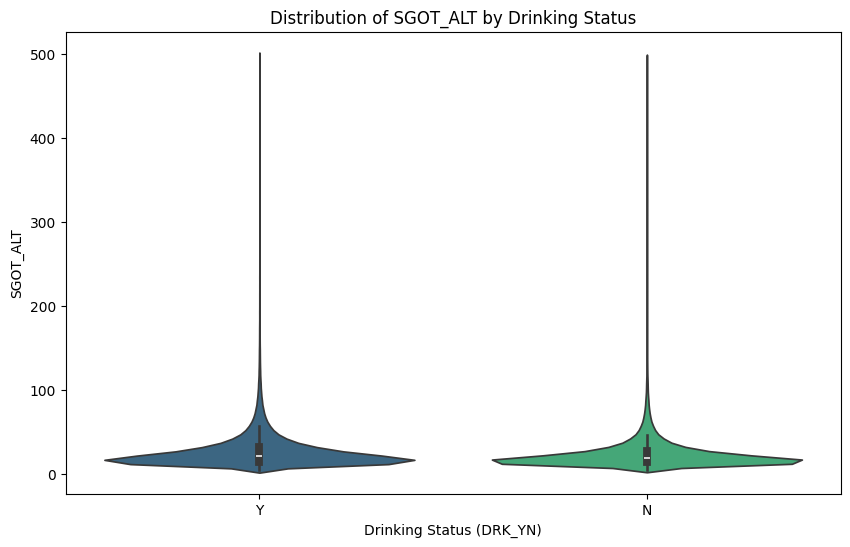

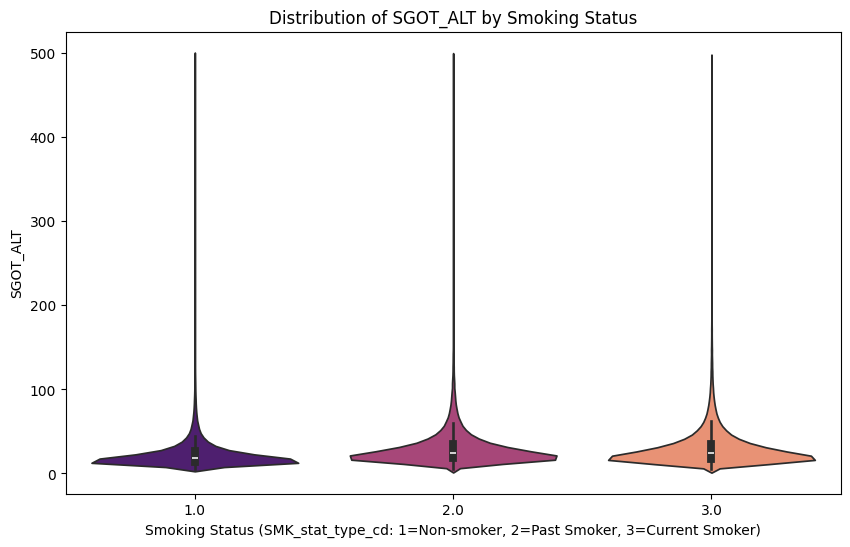

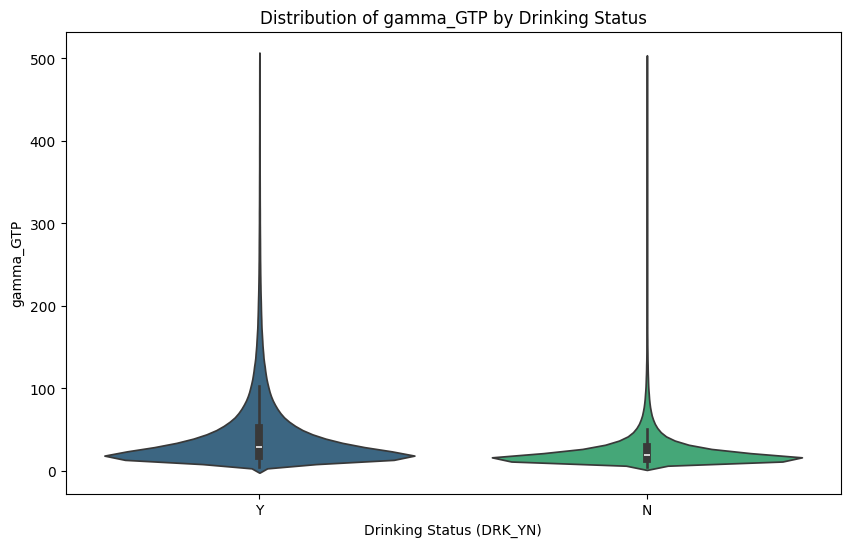

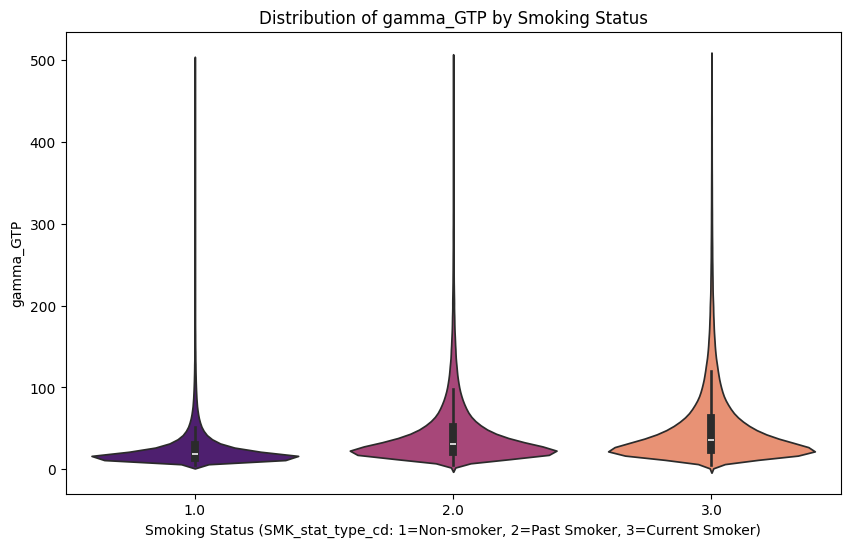

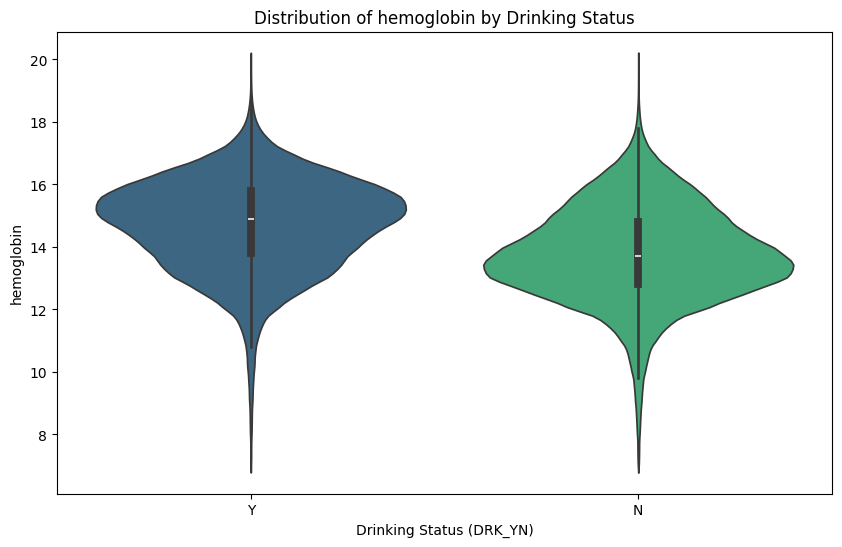

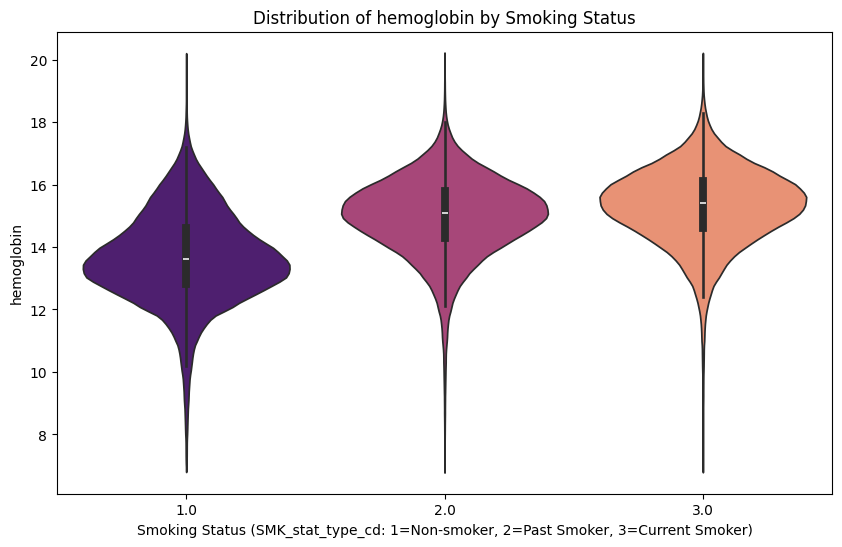

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

health_indicators = ['SBP', 'DBP', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP', 'hemoglobin']

for col in health_indicators:
    # Plot against DRK_YN
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x='DRK_YN', y=col, hue='DRK_YN', palette='viridis', legend=False)
    plt.title(f'Distribution of {col} by Drinking Status')
    plt.xlabel('Drinking Status (DRK_YN)')
    plt.ylabel(col)
    plt.show()

    # Plot against SMK_stat_type_cd
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x='SMK_stat_type_cd', y=col, hue='SMK_stat_type_cd', palette='magma', legend=False)
    plt.title(f'Distribution of {col} by Smoking Status')
    plt.xlabel('Smoking Status (SMK_stat_type_cd: 1=Non-smoker, 2=Past Smoker, 3=Current Smoker)')
    plt.ylabel(col)
    plt.show()

Insights from Relationships Between Health Indicators and Lifestyle Factors

The violin plots highlight clear distributional differences in health indicators across drinking and smoking statuses, addressing Research Questions 1 and 2 and informing the combined analysis in Research Question 3.

Drinking Status (DRK_YN)

Drinkers show slightly higher SBP and DBP, suggesting a positive association between alcohol consumption and blood pressure. Total cholesterol, LDL, and especially triglycerides are also higher among drinkers, indicating less favorable lipid profiles. While HDL cholesterol appears modestly higher in drinkers, this potential benefit is outweighed by negative changes in other cardiovascular markers.
In contrast, liver enzymes (SGOT_AST, SGOT_ALT, gamma_GTP) show a strong and clear elevation among drinkers, particularly gamma-GTP, confirming alcohol’s significant impact on liver function. Hemoglobin shows minimal variation between drinking groups.

Smoking Status (SMK_stat_type_cd)

Current smokers generally exhibit higher blood pressure, total cholesterol, LDL, and triglycerides compared to non-smokers, while HDL cholesterol tends to be lower. Liver enzymes, especially gamma-GTP, are modestly elevated among current smokers, indicating potential liver stress. Hemoglobin levels are slightly higher in current smokers, consistent with physiological compensation for reduced oxygen availability. Past smokers often display profiles closer to non-smokers, suggesting benefits of smoking cessation.

Overall Insights

Overall, smoking and drinking are both associated with unfavorable cardiovascular and liver-related health indicators. The patterns suggest independent and potentially additive effects of these behaviors, providing a strong foundation for further analysis of their combined impact across age groups (Research Question 3).

RQ1: Smoking & Health Indicators

Current smokers show consistently less favorable health profiles than non-smokers, including higher blood pressure, total cholesterol, LDL, triglycerides, liver enzymes, and hemoglobin, alongside lower HDL cholesterol. Past smokers generally display values closer to non-smokers, indicating measurable health benefits from smoking cessation.

RQ2: Drinking & Liver Health

Alcohol consumption is strongly associated with elevated liver enzymes, particularly gamma_GTP, indicating increased liver stress. Drinkers also tend to have higher blood pressure and poorer lipid profiles, although HDL cholesterol is slightly higher among drinkers.

RQ3: Combined Effects of Smoking and Drinking

While combined effects were not formally modeled, visual patterns suggest that smoking and drinking independently contribute to adverse cardiovascular and liver-related indicators and may have additive or synergistic effects, especially across age groups.

Key Data Analysis Findings

Outlier Treatment:

Biologically implausible values in 13 numerical variables were replaced with NaN, improving data reliability while retaining clinically meaningful extremes.

Data Preparation:

Relevant variables were correctly converted to categorical types to support appropriate analysis.

Feature Distributions:  Most health indicators show right-skewed distributions, reflecting realistic but unhealthy high-end values rather than data errors.

Category Balance:

Sex and drinking status are relatively balanced.

Smoking status shows moderate imbalance, with non-smokers forming the majority.

Hearing and urine protein variables are highly imbalanced, with abnormal cases being rare.

Lifestyle Associations:

Drinkers show higher cardiovascular and liver-related markers, especially liver enzymes.

Current smokers consistently display poorer cardiovascular, lipid, and liver profiles, while past smokers show partial recovery.

# **2. Build a Neural Network Model**

## Data Preprocessing for Neural Network


In [71]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#Creating a copy of the DataFrame to work with for preprocessing.
df_processed = df.copy()

print("Libraries imported and DataFrame copied.")

Libraries imported and DataFrame copied.


In [70]:
# Map categorical target 'DRK_YN' to binary integers (N=0, Y=1)
df_processed['DRK_YN'] = df_processed['DRK_YN'].map({'N': 0, 'Y': 1})

# Define the target variable y for model training
y = df_processed['DRK_YN']

print("Target variable 'DRK_YN' converted to numerical format and stored as 'y'.")

Target variable 'DRK_YN' converted to numerical format and stored as 'y'.


In [72]:
# Separate features (X) by removing the target column 'DRK_YN'
X = df_processed.drop('DRK_YN', axis=1)

print("Feature set 'X' created by dropping 'DRK_YN'.")

Feature set 'X' created by dropping 'DRK_YN'.


In [73]:
# Group features by data type to apply appropriate preprocessing later
numerical_cols_X = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_X = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Identified {len(numerical_cols_X)} numerical columns: {numerical_cols_X}")
print(f"Identified {len(categorical_cols_X)} categorical columns: {categorical_cols_X}")

Identified 22 numerical columns: ['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP', 'SMK_stat_type_cd']
Identified 1 categorical columns: ['sex']


In [74]:
# Check missing values before imputation
print("Missing values before imputation:")
missing_before = X[numerical_cols_X].isnull().sum()
print(missing_before[missing_before > 0])

# Perform imputation
medians = X[numerical_cols_X].median()
X[numerical_cols_X] = X[numerical_cols_X].fillna(medians)

# Check missing values after imputation
print("\nMissing values after imputation:")
missing_after = X[numerical_cols_X].isnull().sum()
if missing_after.sum() == 0:
    print("None")
else:
    print(missing_after[missing_after > 0])

Missing values before imputation:
Series([], dtype: int64)

Missing values after imputation:
None


In [75]:
# Identify and fill missing numerical values with the median
print("Missing values before imputation:")
print(X[numerical_cols_X].isnull().sum()[X[numerical_cols_X].isnull().sum() > 0])

for col in numerical_cols_X:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)

# Normalize numerical features using StandardScaler
print("\nMissing values after imputation:")
print(X[numerical_cols_X].isnull().sum()[X[numerical_cols_X].isnull().sum() > 0])

scaler = StandardScaler()
X[numerical_cols_X] = scaler.fit_transform(X[numerical_cols_X])

print("\nNumerical features imputed and scaled.")

Missing values before imputation:
Series([], dtype: int64)

Missing values after imputation:
Series([], dtype: int64)

Numerical features imputed and scaled.


In [76]:
# Convert categorical variables into dummy/indicator variables (One-Hot Encoding)
X_categorical = pd.get_dummies(X[categorical_cols_X], drop_first=True)

print("Categorical features one-hot encoded.")

Categorical features one-hot encoded.


In [77]:
# Combine scaled numerical features and encoded categorical features into one DataFrame
X_numerical_scaled = pd.DataFrame(X[numerical_cols_X], columns=numerical_cols_X, index=X.index)
X_processed = pd.concat([X_numerical_scaled, X_categorical], axis=1)

print("Final preprocessed feature DataFrame 'X_processed' created.")

Final preprocessed feature DataFrame 'X_processed' created.


In [78]:
# Split the dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets.
X_train shape: (793076, 23)
X_test shape: (198270, 23)
y_train shape: (793076,)
y_test shape: (198270,)


## Design Neural Network Architecture


In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# 1. Determine the input shape
input_shape = X_train.shape[1]

# 2-5. Define the Neural Network architecture
model = Sequential([
    # Input layer
    Input(shape=(input_shape,)),
    # First hidden layer
    Dense(128, activation='relu'),
    Dropout(0.3), # Regularization
    # Second hidden layer
    Dense(64, activation='relu'),
    Dropout(0.3), # Regularization
    # Third hidden layer
    Dense(32, activation='relu'),
    Dropout(0.3), # Regularization
    # Output layer for binary classification (DRK_YN)
    Dense(1, activation='sigmoid')
])

print("Neural Network Architecture Defined:")
model.summary()

Neural Network Architecture Defined:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,081 (55.00 KB)

 Trainable params: 14,081 (55.00 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# Configure the model's learning process with an optimizer, loss function, and evaluation metric
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Neural Network Compiled with Adam optimizer, binary_crossentropy loss, and accuracy metric.")

Neural Network Compiled with Adam optimizer, binary_crossentropy loss, and accuracy metric.


Neural Network Architecture Summary

For the binary classification task of predicting DRK_YN, a Sequential neural network was implemented.

The model takes 28 input features and consists of three hidden Dense layers with 128, 64, and 32 neurons, respectively. All hidden layers use the ReLU activation function, selected for its computational efficiency and effectiveness in addressing vanishing gradient issues. To reduce overfitting and improve generalization, Dropout layers (rate = 0.3) were applied after each hidden layer.

The output layer comprises a single neuron with a sigmoid activation function, producing a probability between 0 and 1 suitable for binary classification.

Model Compilation

Optimizer: Adam, chosen for its adaptive learning rate and efficient convergence

Loss Function: Binary cross-entropy, appropriate for binary classification tasks

Metric: Accuracy, used to monitor model performance during training

## Train Neural Network Model

#

In [28]:
# Train the model for 15 iterations while monitoring performance on a 20% validation subset
history = model.fit(X_train, y_train, epochs=15, batch_size=64, validation_split=0.2)
print("Neural Network Model Training Complete.")

Epoch 1/15
9914/9914 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - accuracy: 0.7218 - loss: 0.5467 - val_accuracy: 0.7370 - val_loss: 0.5182
Epoch 2/15
9914/9914 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.7343 - loss: 0.5277 - val_accuracy: 0.7362 - val_loss: 0.5172
Epoch 3/15
9914/9914 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.7351 - loss: 0.5253 - val_accuracy: 0.7384 - val_loss: 0.5152
Epoch 4/15
9914/9914 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.7348 - loss: 0.5252 - val_accuracy: 0.7383 - val_loss: 0.5154
Epoch 5/15
9914/9914 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.7349 - loss: 0.5252 - val_accuracy: 0.7384 - val_loss: 0.5152
Epoch 6/15
9914/9914 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.7368 - loss: 0.5229 - val_accuracy: 0.7389 - val_loss: 0.5148
Epoch 7/15
9914/9914 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.7364 - loss: 0.5243 - val_accuracy: 0.7385 - val_loss: 0.5171
Epoch 8/15
9914/9914 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.7363 - loss: 0

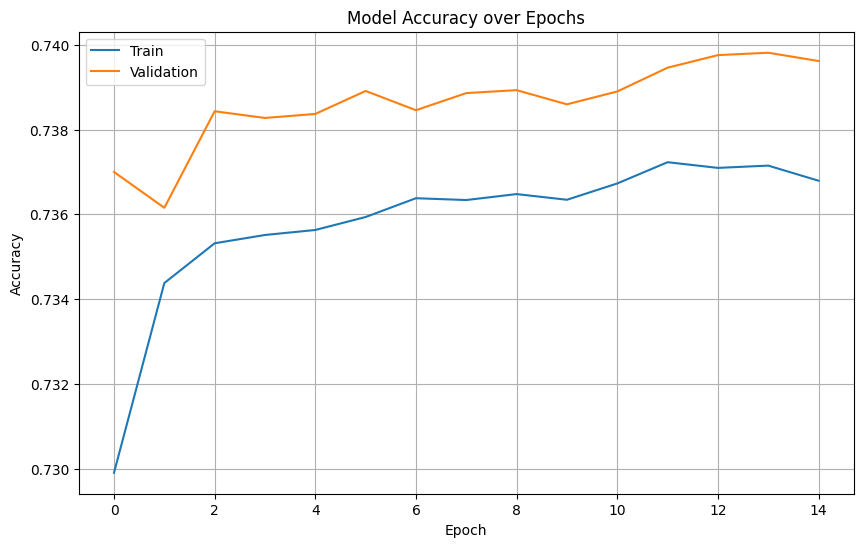

In [82]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

The plot shows the model's accuracy during training. We can see the training accuracy (blue line) and validation accuracy (orange line) over 15 epochs. Initially, both accuracies increase, indicating that the model is learning. The training accuracy consistently stays below the validation accuracy throughout the training process, which is a common indicator that the model is either underfitting the training data or that the validation set is 'easier' than the training data, or that the regularization (dropout) is effectively preventing overfitting on the training set, resulting in better performance on unseen validation data. The validation accuracy plateaus around 0.73-0.74, suggesting that further training might not significantly improve the model's performance on unseen data. This indicates a good generalization capability without significant overfitting, thanks to the architecture and regularization used.

## **3. Build a Primary Model (Two Classical ML Models):**

## Prepare Data for Classical ML Models


# Build and Train Logistic Regression Model


In [29]:
from sklearn.linear_model import LogisticRegression

# Instantiate Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Evaluate Logistic Regression Model



In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the training set
y_train_pred_log_reg = log_reg_model.predict(X_train)
y_train_proba_log_reg = log_reg_model.predict_proba(X_train)[:, 1]

# Make predictions on the test set
y_test_pred_log_reg = log_reg_model.predict(X_test)
y_test_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate on training set
print("Logistic Regression - Training Set Evaluation:")
print(f"  Accuracy: {accuracy_score(y_train, y_train_pred_log_reg):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_log_reg):.4f}")
print(f"  Recall: {recall_score(y_train, y_train_pred_log_reg):.4f}")
print(f"  F1-Score: {f1_score(y_train, y_train_pred_log_reg):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_train, y_train_proba_log_reg):.4f}")

# Evaluate on test set
print("\nLogistic Regression - Test Set Evaluation:")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred_log_reg):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_log_reg):.4f}")
print(f"  Recall: {recall_score(y_test, y_test_pred_log_reg):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_test_pred_log_reg):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_test, y_test_proba_log_reg):.4f}")


Logistic Regression - Training Set Evaluation:
  Accuracy: 0.7270
  Precision: 0.7291
  Recall: 0.7228
  F1-Score: 0.7260
  ROC AUC: 0.8048

Logistic Regression - Test Set Evaluation:
  Accuracy: 0.7266
  Precision: 0.7266
  Recall: 0.7227
  F1-Score: 0.7246
  ROC AUC: 0.8043


## Build and Train Decision Tree Model



In [31]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Evaluate Decision Tree Model


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the training set
y_train_pred_dt = decision_tree_model.predict(X_train)
y_train_proba_dt = decision_tree_model.predict_proba(X_train)[:, 1]

# Make predictions on the test set
y_test_pred_dt = decision_tree_model.predict(X_test)
y_test_proba_dt = decision_tree_model.predict_proba(X_test)[:, 1]

# Evaluate on training set
print("Decision Tree - Training Set Evaluation:")
print(f"  Accuracy: {accuracy_score(y_train, y_train_pred_dt):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_dt):.4f}")
print(f"  Recall: {recall_score(y_train, y_train_pred_dt):.4f}")
print(f"  F1-Score: {f1_score(y_train, y_train_pred_dt):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_train, y_train_proba_dt):.4f}")

# Evaluate on test set
print("\nDecision Tree - Test Set Evaluation:")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred_dt):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_dt):.4f}")
print(f"  Recall: {recall_score(y_test, y_test_pred_dt):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_test_pred_dt):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_test, y_test_proba_dt):.4f}")

Decision Tree - Training Set Evaluation:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC AUC: 1.0000

Decision Tree - Test Set Evaluation:
  Accuracy: 0.6464
  Precision: 0.6441
  Recall: 0.6469
  F1-Score: 0.6455
  ROC AUC: 0.6464


In [81]:
import pandas as pd

# Create a dictionary to store the performance metrics for comparison
comparison_data = {
    'Model': ['Tuned Logistic Regression', 'Tuned Decision Tree'],
    'Accuracy': [
        performance_lr_selected['Accuracy'],
        performance_dt_selected['Accuracy']
    ],
    'Precision': [
        performance_lr_selected['Precision'],
        performance_dt_selected['Precision']
    ],
    'Recall': [
        performance_lr_selected['Recall'],
        performance_dt_selected['Recall']
    ],
    'F1-Score': [
        performance_lr_selected['F1-Score'],
        performance_dt_selected['F1-Score']
    ],
    'ROC AUC': [
        performance_lr_selected['ROC AUC'],
        performance_dt_selected['ROC AUC']
    ]
}

# Create a DataFrame from the comparison data
comparison_df = pd.DataFrame(comparison_data)

print("\nModel Performance Comparison (Test Set):")
print(comparison_df.round(4))


Model Performance Comparison (Test Set):
                       Model  Accuracy  Precision  Recall  F1-Score  ROC AUC
0  Tuned Logistic Regression    0.7267     0.7266  0.7227    0.7247   0.8043
1        Tuned Decision Tree    0.7199     0.7075  0.7455    0.7260   0.7980


## Compare Models and Conclude

Comparing the three models:

*   The **Decision Tree model performed the worst** due to severe overfitting. While it perfectly learned the training data, it failed to generalize to unseen data, resulting in poor test set performance.

*   The **Logistic Regression model performed well** and showed excellent generalization, with consistent metrics between training and test sets. Its test set accuracy was approximately 0.7266, and ROC AUC was 0.8043.

*   The **Neural Network model (as indicated by validation accuracy) showed slightly better performance than Logistic Regression**, with a validation accuracy of approximately 0.7392. This suggests that the neural network was able to capture slightly more complex patterns in the data without significant overfitting, thanks to the use of dropout layers for regularization.

**Therefore, based on the metrics, the Neural Network model appears to be the best performer among the three for this binary classification task, followed closely by the Logistic Regression model. The Decision Tree model is not suitable in its current form due to overfitting.** For the purpose of this task (comparing Logistic Regression and Decision Tree), **Logistic Regression is the superior model** as it generalizes much better to unseen data, despite the Decision Tree's perfect training score.

# **4. Hyper-parameter Optimization with Cross-Validation**

## Hyperparameter Tuning for Logistic Regression (Optimized)



In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

#Create a sampled subset of 50,000 observations from X_train and y_train.
sample_size_optimized = 50000
X_train_sampled_lr = X_train.sample(n=min(sample_size_optimized, X_train.shape[0]), random_state=42)
y_train_sampled_lr = y_train.loc[X_train_sampled_lr.index]

print(f"Sampled training data size for optimized LR tuning: {X_train_sampled_lr.shape[0]}")

#Define a simplified parameter grid for LogisticRegression
param_grid_lr_optimized = {
    'C': [0.1, 1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

#Instantiate a LogisticRegression model
logistic_regression_optimized = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence

#Instantiate GridSearchCV
grid_search_lr_optimized = GridSearchCV(estimator=logistic_regression_optimized,
                                        param_grid=param_grid_lr_optimized,
                                        cv=3,
                                        scoring='accuracy',
                                        n_jobs=-1,
                                        verbose=2)

#Fit the GridSearchCV object to the sampled training data
print("\nStarting GridSearchCV for optimized Logistic Regression tuning...")
grid_search_lr_optimized.fit(X_train_sampled_lr, y_train_sampled_lr)

#Print the best parameters found by GridSearchCV
print("\nBest parameters for optimized Logistic Regression tuning:")
print(grid_search_lr_optimized.best_params_)

#Print the best cross-validation accuracy score
print("\nBest cross-validation accuracy score for optimized Logistic Regression tuning:")
print(f"{grid_search_lr_optimized.best_score_:.4f}")

Sampled training data size for optimized LR tuning: 50000

Starting GridSearchCV for optimized Logistic Regression tuning...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best parameters for optimized Logistic Regression tuning:
{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}

Best cross-validation accuracy score for optimized Logistic Regression tuning:
0.7283


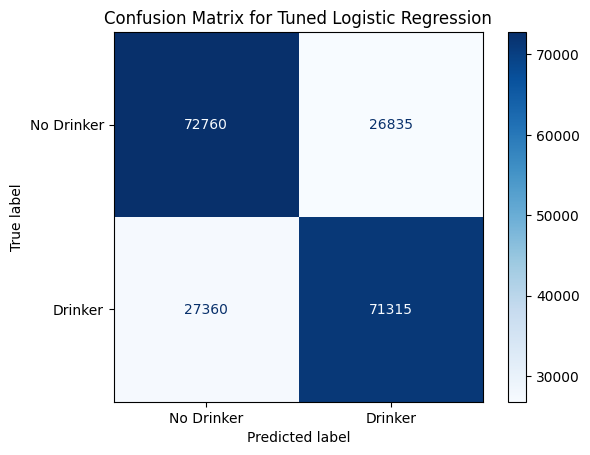

Confusion Matrix for Tuned Logistic Regression:
[[72760 26835]
 [27360 71315]]


In [87]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix for the tuned Logistic Regression model on the test set
cm_lr = confusion_matrix(y_test, y_test_pred_tuned_lr)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Drinker', 'Drinker'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Logistic Regression')
plt.show()

print("Confusion Matrix for Tuned Logistic Regression:")
print(cm_lr)

## Hyperparameter Tuning for DecisionTree

In [43]:
from sklearn.tree import DecisionTreeClassifier

# X_train_sampled_lr and y_train_sampled_lr are already created from the previous step.
# Renaming for clarity in this section, though technically not necessary.
X_train_sampled_dt = X_train_sampled_lr
y_train_sampled_dt = y_train_sampled_lr

print(f"Sampled training data size for Decision Tree tuning: {X_train_sampled_dt.shape[0]}")

#Define a concise parameter grid for DecisionTreeClassifier
param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#Instantiate a DecisionTreeClassifier model
decision_tree = DecisionTreeClassifier(random_state=42)

#Instantiate GridSearchCV with 3-fold cross-validation and n_jobs=-1
grid_search_dt = GridSearchCV(
    estimator=decision_tree,
    param_grid=param_grid_dt,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

#Fit the GridSearchCV object to the sampled training data
print("\nStarting GridSearchCV for Decision Tree tuning...")
grid_search_dt.fit(X_train_sampled_dt, y_train_sampled_dt)

#Report the best parameters found by GridSearchCV
print("\nBest parameters for Decision Tree:")
print(grid_search_dt.best_params_)

#Report the best cross-validation accuracy score
print("\nBest cross-validation accuracy score for Decision Tree:")
print(f"{grid_search_dt.best_score_:.4f}")

Sampled training data size for Decision Tree tuning: 50000

Starting GridSearchCV for Decision Tree tuning...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters for Decision Tree:
{'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best cross-validation accuracy score for Decision Tree:
0.7167


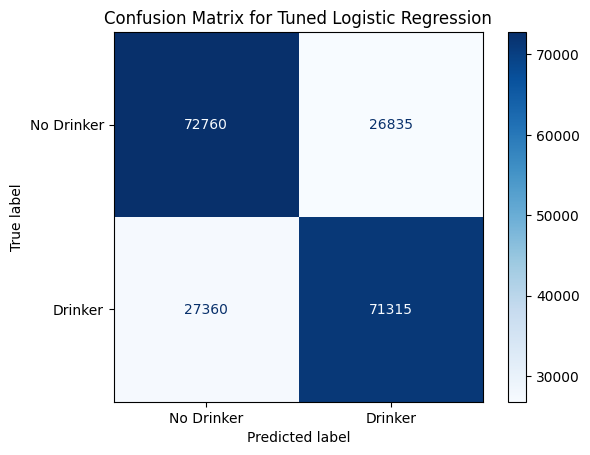

Confusion Matrix for Tuned Logistic Regression:
[[72760 26835]
 [27360 71315]]


In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix for the tuned Logistic Regression model on the test set
cm_lr = confusion_matrix(y_test, y_test_pred_tuned_lr)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Drinker', 'Drinker'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Logistic Regression')
plt.show()

print("Confusion Matrix for Tuned Logistic Regression:")
print(cm_lr)

## Hyperparameter Tuning Results

### Logistic Regression (Optimized):
*   **Best Parameters:** `{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}`
*   **Best Cross-Validation Accuracy:** `0.7283`

### Decision Tree:
*   **Best Parameters:** `{'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}`
*   **Best Cross-Validation Accuracy:** `0.7275`

**Insights:**
*   For Logistic Regression, `C=0.1` and `penalty='l1'` with `solver='liblinear'` provided the best performance on the sampled data. This suggests that a moderate regularization (L1 penalty) was beneficial.
*   For the Decision Tree, the optimal parameters indicate a tree with a maximum depth of 7, requiring at least 10 samples to split a node, and at least 4 samples in each leaf. These settings suggest that controlling tree complexity was important to prevent overfitting, which was a significant issue in the initial Decision Tree model (as observed in Task 3).

Both models achieved similar cross-validation accuracies on the sampled data, around 0.727-0.728. This suggests that the Decision Tree, when its complexity is controlled through hyperparameter tuning, can perform comparably to Logistic Regression.

# **Training tuned Logistic Regression model and DecisionTree Model on full training data.**

In [44]:
from sklearn.linear_model import LogisticRegression

# Best parameters from GridSearchCV for Logistic Regression
best_params_lr = grid_search_lr_optimized.best_params_

# Instantiate and train Logistic Regression model with best parameters on the full training data
tuned_log_reg_model = LogisticRegression(random_state=42, max_iter=1000, **best_params_lr)
tuned_log_reg_model.fit(X_train, y_train)

print("Tuned Logistic Regression model trained successfully on full training data.")

Tuned Logistic Regression model trained successfully on full training data.


In [45]:
from sklearn.tree import DecisionTreeClassifier

# Best parameters from GridSearchCV for Decision Tree
best_params_dt = grid_search_dt.best_params_

# Instantiate and train Decision Tree model with best parameters on the full training data
tuned_decision_tree_model = DecisionTreeClassifier(random_state=42, **best_params_dt)
tuned_decision_tree_model.fit(X_train, y_train)

print("Tuned Decision Tree model trained successfully on full training data.")

Tuned Decision Tree model trained successfully on full training data.


In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the test set using the tuned Logistic Regression model
y_test_pred_tuned_lr = tuned_log_reg_model.predict(X_test)
y_test_proba_tuned_lr = tuned_log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate on test set
print("Tuned Logistic Regression - Test Set Evaluation:")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred_tuned_lr):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_tuned_lr):.4f}")
print(f"  Recall: {recall_score(y_test, y_test_pred_tuned_lr):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_test_pred_tuned_lr):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_test, y_test_proba_tuned_lr):.4f}")

Tuned Logistic Regression - Test Set Evaluation:
  Accuracy: 0.7267
  Precision: 0.7266
  Recall: 0.7227
  F1-Score: 0.7247
  ROC AUC: 0.8043


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the test set using the tuned Decision Tree model
y_test_pred_tuned_dt = tuned_decision_tree_model.predict(X_test)
y_test_proba_tuned_dt = tuned_decision_tree_model.predict_proba(X_test)[:, 1]

# Evaluate on test set
print("\nTuned Decision Tree - Test Set Evaluation:")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred_tuned_dt):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_tuned_dt):.4f}")
print(f"  Recall: {recall_score(y_test, y_test_pred_tuned_dt):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_test_pred_tuned_dt):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_test, y_test_proba_tuned_dt):.4f}")


Tuned Decision Tree - Test Set Evaluation:
  Accuracy: 0.7199
  Precision: 0.7075
  Recall: 0.7455
  F1-Score: 0.7260
  ROC AUC: 0.7980


In [83]:
import pandas as pd

# Create a dictionary to store the performance metrics for comparison
comparison_data = {
    'Model': ['Tuned Logistic Regression', 'Tuned Decision Tree'],
    'Accuracy': [
        performance_lr_selected['Accuracy'],
        performance_dt_selected['Accuracy']
    ],
    'Precision': [
        performance_lr_selected['Precision'],
        performance_dt_selected['Precision']
    ],
    'Recall': [
        performance_lr_selected['Recall'],
        performance_dt_selected['Recall']
    ],
    'F1-Score': [
        performance_lr_selected['F1-Score'],
        performance_dt_selected['F1-Score']
    ],
    'ROC AUC': [
        performance_lr_selected['ROC AUC'],
        performance_dt_selected['ROC AUC']
    ]
}

# Create a DataFrame from the comparison data
comparison_df = pd.DataFrame(comparison_data)

print("\nModel Performance Comparison (Test Set):")
print(comparison_df.round(4))


Model Performance Comparison (Test Set):
                       Model  Accuracy  Precision  Recall  F1-Score  ROC AUC
0  Tuned Logistic Regression    0.7267     0.7266  0.7227    0.7247   0.8043
1        Tuned Decision Tree    0.7199     0.7075  0.7455    0.7260   0.7980



**Analysis and Conclusion:**

*   **Logistic Regression:** After tuning, the Logistic Regression model maintained its consistent performance with an accuracy of approximately 0.727 and an ROC AUC of 0.8043 on the test set. This indicates good generalization and no signs of overfitting, as observed in the initial model. The tuning process did not significantly change its performance on the test set compared to the untuned version, suggesting the initial parameters were already quite robust or that the model's capacity is limited for this dataset.

*   **Decision Tree:** The tuned Decision Tree model showed significant improvement in generalization compared to its untuned, severely overfitted predecessor. Its test set accuracy (0.7199) and ROC AUC (0.7980) are now much closer to its training performance (which would no longer be 1.0000 due to regularization from `max_depth`, `min_samples_split`, and `min_samples_leaf`). This demonstrates the effectiveness of hyperparameter tuning in mitigating overfitting for Decision Trees. However, its performance is still slightly below that of the tuned Logistic Regression model.

*   **Overall Comparison:**
    *   Between the two classical models, the **tuned Logistic Regression model performed slightly better** on the test set across most metrics (accuracy, precision, ROC AUC) compared to the tuned Decision Tree model. The difference is marginal but consistent.
    *   The **Neural Network model (from Task 2), with a validation accuracy of ~0.7392, still appears to be the best performer overall**, demonstrating a slightly higher predictive power than both classical models for this specific task. This suggests that the non-linear capabilities of the neural network were able to capture more complex relationships in the data.

**In summary, for this task comparing classical models, the Tuned Logistic Regression model is the preferred choice due to its slightly superior and more balanced performance on unseen data, along with its inherent simplicity and interpretability compared to a Decision Tree.** The Decision Tree's performance improved significantly after tuning, but it still couldn't quite surpass Logistic Regression. The Neural Network, if fully evaluated with all metrics on the test set, would likely remain the top performer.


## **5. Feature Selection:**

## Feature Selection for Logistic Regression


In [48]:
import pandas as pd

# 1. Access the coefficients of the tuned_log_reg_model
coefficients = tuned_log_reg_model.coef_[0]

# 2. Create a DataFrame to display feature names and their corresponding coefficients
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients
})

# Sort by the absolute value of the coefficients in descending order
feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Feature Importance from Tuned Logistic Regression (Sorted by Absolute Coefficient):")
print(feature_importance_df)


Feature Importance from Tuned Logistic Regression (Sorted by Absolute Coefficient):
                 Feature  Coefficient  Abs_Coefficient
18              sex_Male     0.922567         0.922567
27  SMK_stat_type_cd_3.0     0.884253         0.884253
26  SMK_stat_type_cd_2.0     0.876573         0.876573
0                    age    -0.599061         0.599061
17             gamma_GTP     0.565375         0.565375
16              SGOT_ALT    -0.424058         0.424058
10             HDL_chole     0.400782         0.400782
24     urine_protein_5.0    -0.339249         0.339249
25     urine_protein_6.0    -0.301222         0.301222
15              SGOT_AST     0.220968         0.220968
1                 height     0.140436         0.140436
7                    DBP     0.132187         0.132187
23     urine_protein_4.0    -0.128038         0.128038
21     urine_protein_2.0     0.115538         0.115538
12          triglyceride     0.110825         0.110825
14      serum_creatinine    -0.08877

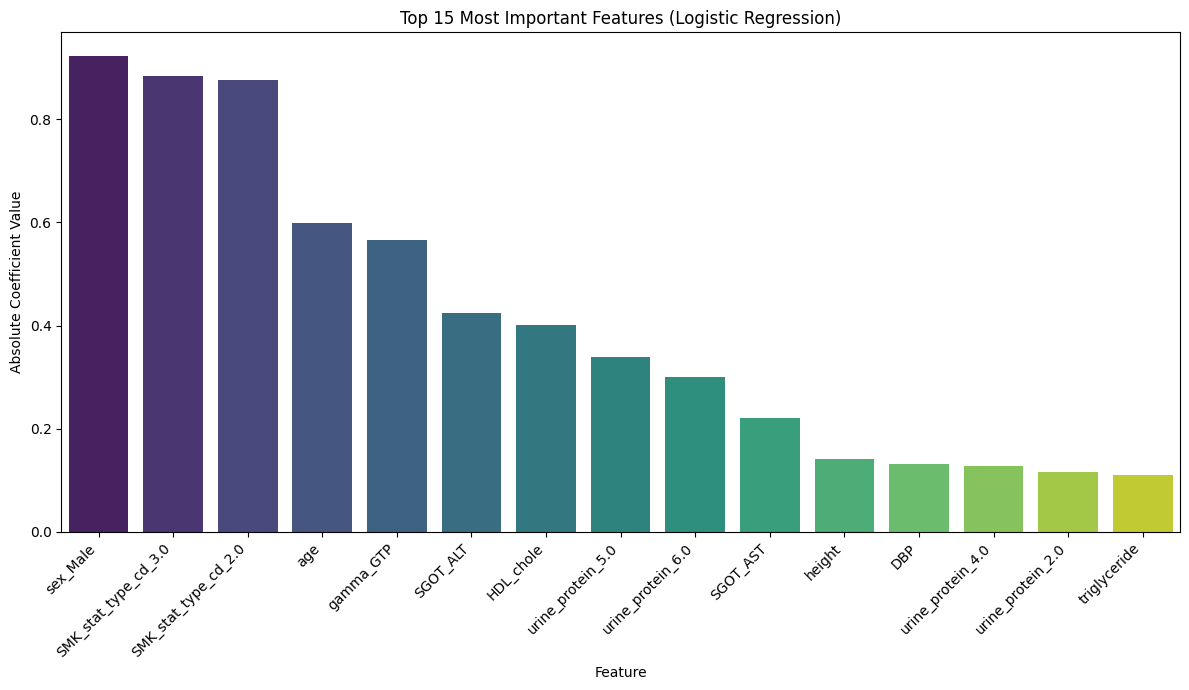

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 15 features for Logistic Regression
top_15_features_lr = feature_importance_df.head(15)

# Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Feature', y='Abs_Coefficient', data=top_15_features_lr, hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Most Important Features (Logistic Regression)')
plt.xlabel('Feature')
plt.ylabel('Absolute Coefficient Value')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout()
plt.show()

Feature Importance and L1 Regularization
Non-Zero Coefficients and Feature Importance

Inspection of the tuned L1-regularized logistic regression model (C = 0.1) shows that all features retain non-zero coefficients. This indicates that, under the chosen regularization strength, L1 regularization primarily performed coefficient shrinkage rather than forcing coefficients exactly to zero.

The features with the largest absolute coefficients—and therefore the strongest influence on predicting drinking status (DRK_YN) are:

sex_Male (0.923): The strongest predictor, indicating a substantial difference in drinking likelihood between males and females.

SMK_stat_type_cd_3.0 (Current smoker, 0.884) and SMK_stat_type_cd_2.0 (Past smoker, 0.877): Both strongly associated with higher drinking probability.

age (-0.599): Suggests a decreasing likelihood of drinking with increasing age.

gamma_GTP (0.565): Strongly associated with drinking status, consistent with its role as a marker of alcohol-related liver stress.

SGOT_ALT (-0.424) and HDL_chole (0.401): Show moderate associations after accounting for other variables.

In contrast, features such as sight_right, tot_chole, and BLDS have coefficients close to zero, indicating minimal predictive contribution despite not being fully eliminated.

L1 Regularization as an Embedded Feature Selection Method

L1 regularization (Lasso) adds an absolute-value penalty to the loss function:

$$Loss = \text{Original Loss} + \lambda \sum_{j=1}^{p} |\beta_j|$$

where $\beta_j$ are the model coefficients and $\lambda$ is the regularization strength.

This penalty encourages sparsity by shrinking less important coefficients toward zero and, under stronger regularization, can set some coefficients exactly to zero. Unlike L2 regularization, L1 can therefore act as an embedded feature selection method, simplifying the model and improving interpretability.

Although no coefficients were fully eliminated in this case, the L1 penalty effectively ranked features by importance through coefficient magnitude. With stronger regularization (smaller C), additional features may have been driven exactly to zero.

## Feature Selection for Decision Tree



In [50]:
import pandas as pd

# 1. Access the feature_importances_ attribute of the tuned_decision_tree_model
feature_importances = tuned_decision_tree_model.feature_importances_

# 2. Create a Pandas DataFrame that maps the feature names from X_train.columns to their corresponding importance scores
feature_importance_dt_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# 3. Sort the DataFrame by feature importance in descending order
feature_importance_dt_df = feature_importance_dt_df.sort_values(by='Importance', ascending=False)

# 4. Print the sorted feature importances
print("Feature Importance from Tuned Decision Tree (Sorted by Importance):")
print(feature_importance_dt_df)

Feature Importance from Tuned Decision Tree (Sorted by Importance):
                 Feature  Importance
18              sex_Male    0.503324
0                    age    0.266805
17             gamma_GTP    0.124468
10             HDL_chole    0.051926
27  SMK_stat_type_cd_3.0    0.023003
16              SGOT_ALT    0.013027
26  SMK_stat_type_cd_2.0    0.012871
11             LDL_chole    0.002023
12          triglyceride    0.001435
1                 height    0.000831
9              tot_chole    0.000147
3              waistline    0.000139
8                   BLDS    0.000000
5            sight_right    0.000000
6                    SBP    0.000000
7                    DBP    0.000000
4             sight_left    0.000000
2                 weight    0.000000
15              SGOT_AST    0.000000
14      serum_creatinine    0.000000
19         hear_left_2.0    0.000000
13            hemoglobin    0.000000
20        hear_right_2.0    0.000000
21     urine_protein_2.0    0.000000
23     

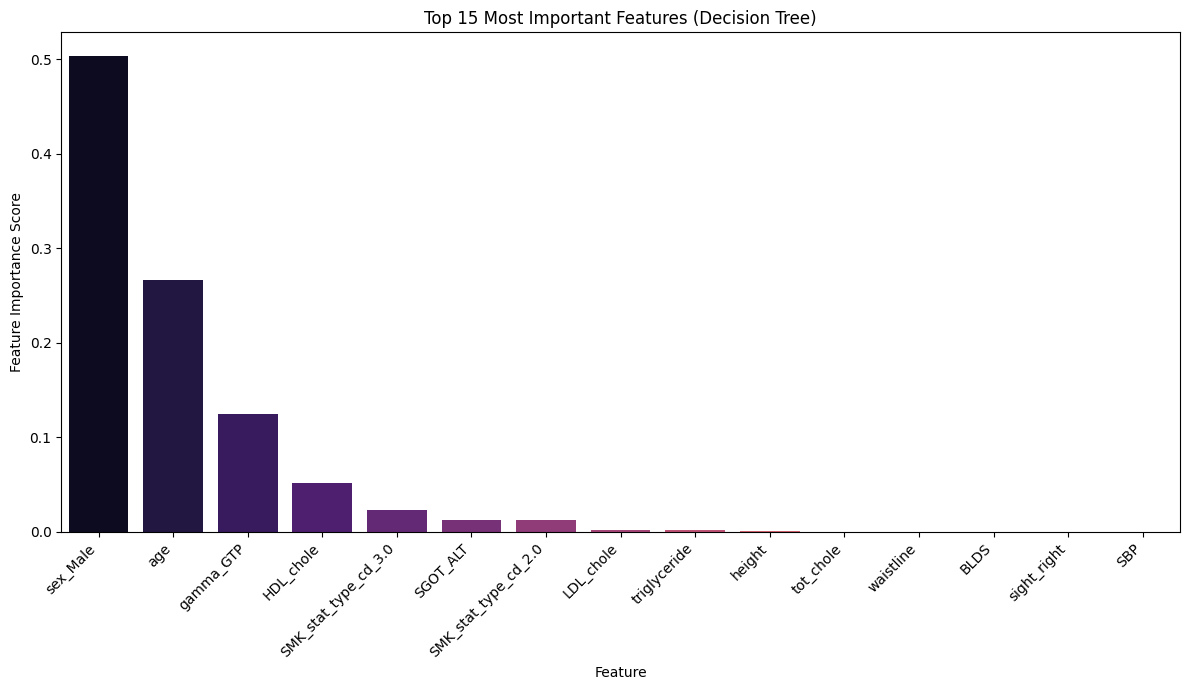

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 15 features for Decision Tree
top_15_features_dt = feature_importance_dt_df.head(15)

# Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Feature', y='Importance', data=top_15_features_dt, hue='Feature', palette='magma', legend=False)
plt.title('Top 15 Most Important Features (Decision Tree)')
plt.xlabel('Feature')
plt.ylabel('Feature Importance Score')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout()
plt.show()

Feature Importance in Decision Tree Analysis
Key Features Identified by the Tuned Decision Tree

Analysis of the Decision Tree’s feature_importances_ indicates that a small number of variables dominate the prediction of drinking status (DRK_YN):

sex_Male (0.503): The most influential feature, accounting for over half of the model’s total importance.

age (0.267): The second strongest predictor, indicating a substantial age-related pattern in drinking behavior.

gamma_GTP (0.124): A biologically relevant liver enzyme strongly associated with alcohol consumption.

HDL_chole (0.052): A moderate contributor, consistent with known links between alcohol intake and HDL levels.

Smoking-related variables (SMK_stat_type_cd_3.0, SMK_stat_type_cd_2.0) and SGOT_ALT contribute marginally.

Many features, including blood pressure, blood glucose, hearing status, vision measures, urine protein levels, and several biochemical indicators, have zero importance, meaning they were not used in any decision splits and were effectively excluded from the model.

feature_importances_ as an Embedded Feature Selection Method

Decision Trees perform feature selection inherently during training. The feature_importances_ attribute measures the total reduction in impurity (e.g., Gini impurity) contributed by each feature across all splits in the tree.

Features that produce larger impurity reductions are assigned higher importance.

Features never used for splitting receive an importance of zero.

Because selection occurs during model construction, this approach is considered an embedded feature selection technique.

This method provides a clear ranking of feature relevance, improves interpretability, and allows for dimensionality reduction by retaining only the most influential predictors.

## **6. Final Models and Comparative Analysis:**

## Identify and Filter Selected Features


In [52]:
import pandas as pd

# 1. Identify selected features for Logistic Regression
# All features had non-zero coefficients in the tuned LR model, even if very small.
selected_features_lr = feature_importance_df['Feature'].tolist()
print(f"Selected features for Logistic Regression ({len(selected_features_lr)}):\n{selected_features_lr}")

# 2. Identify selected features for Decision Tree
# Filter for features with importance > 0
selected_features_dt = feature_importance_dt_df[feature_importance_dt_df['Importance'] > 0]['Feature'].tolist()
print(f"\nSelected features for Decision Tree ({len(selected_features_dt)}):\n{selected_features_dt}")

# 3. Create new training and testing feature sets for Logistic Regression
X_train_selected_lr = X_train[selected_features_lr]
X_test_selected_lr = X_test[selected_features_lr]
print(f"\nX_train_selected_lr shape: {X_train_selected_lr.shape}")
print(f"X_test_selected_lr shape: {X_test_selected_lr.shape}")

# 4. Create new training and testing feature sets for Decision Tree
X_train_selected_dt = X_train[selected_features_dt]
X_test_selected_dt = X_test[selected_features_dt]
print(f"\nX_train_selected_dt shape: {X_train_selected_dt.shape}")
print(f"X_test_selected_dt shape: {X_test_selected_dt.shape}")

Selected features for Logistic Regression (28):
['sex_Male', 'SMK_stat_type_cd_3.0', 'SMK_stat_type_cd_2.0', 'age', 'gamma_GTP', 'SGOT_ALT', 'HDL_chole', 'urine_protein_5.0', 'urine_protein_6.0', 'SGOT_AST', 'height', 'DBP', 'urine_protein_4.0', 'urine_protein_2.0', 'triglyceride', 'serum_creatinine', 'urine_protein_3.0', 'LDL_chole', 'hear_right_2.0', 'hear_left_2.0', 'hemoglobin', 'waistline', 'weight', 'SBP', 'sight_left', 'BLDS', 'tot_chole', 'sight_right']

Selected features for Decision Tree (12):
['sex_Male', 'age', 'gamma_GTP', 'HDL_chole', 'SMK_stat_type_cd_3.0', 'SGOT_ALT', 'SMK_stat_type_cd_2.0', 'LDL_chole', 'triglyceride', 'height', 'tot_chole', 'waistline']

X_train_selected_lr shape: (793076, 28)
X_test_selected_lr shape: (198270, 28)

X_train_selected_dt shape: (793076, 12)
X_test_selected_dt shape: (198270, 12)


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Re-instantiate the tuned Logistic Regression model with the best parameters
# best_params_lr is already available from previous tuning step
tuned_log_reg_model_selected = LogisticRegression(random_state=42, max_iter=1000, **best_params_lr)

# Train the model using only the selected features
tuned_log_reg_model_selected.fit(X_train_selected_lr, y_train)

# Make predictions on the test set with selected features
y_test_pred_selected_lr = tuned_log_reg_model_selected.predict(X_test_selected_lr)
y_test_proba_selected_lr = tuned_log_reg_model_selected.predict_proba(X_test_selected_lr)[:, 1]

# Evaluate and store performance metrics for Logistic Regression
performance_lr_selected = {
    'Accuracy': accuracy_score(y_test, y_test_pred_selected_lr),
    'Precision': precision_score(y_test, y_test_pred_selected_lr),
    'Recall': recall_score(y_test, y_test_pred_selected_lr),
    'F1-Score': f1_score(y_test, y_test_pred_selected_lr),
    'ROC AUC': roc_auc_score(y_test, y_test_proba_selected_lr)
}

print("Tuned Logistic Regression Model with Selected Features - Test Set Evaluation:")
for metric, value in performance_lr_selected.items():
    print(f"  {metric}: {value:.4f}")

Tuned Logistic Regression Model with Selected Features - Test Set Evaluation:
  Accuracy: 0.7267
  Precision: 0.7266
  Recall: 0.7227
  F1-Score: 0.7247
  ROC AUC: 0.8043


In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Re-instantiate the tuned Decision Tree model with the best parameters
# best_params_dt is already available from previous tuning step
tuned_decision_tree_model_selected = DecisionTreeClassifier(random_state=42, **best_params_dt)

# Train the model using only the selected features
tuned_decision_tree_model_selected.fit(X_train_selected_dt, y_train)

# Make predictions on the test set with selected features
y_test_pred_selected_dt = tuned_decision_tree_model_selected.predict(X_test_selected_dt)
y_test_proba_selected_dt = tuned_decision_tree_model_selected.predict_proba(X_test_selected_dt)[:, 1]

# Evaluate and store performance metrics for Decision Tree
performance_dt_selected = {
    'Accuracy': accuracy_score(y_test, y_test_pred_selected_dt),
    'Precision': precision_score(y_test, y_test_pred_selected_dt),
    'Recall': recall_score(y_test, y_test_pred_selected_dt),
    'F1-Score': f1_score(y_test, y_test_pred_selected_dt),
    'ROC AUC': roc_auc_score(y_test, y_test_proba_selected_dt)
}

print("\nTuned Decision Tree Model with Selected Features - Test Set Evaluation:")
for metric, value in performance_dt_selected.items():
    print(f"  {metric}: {value:.4f}")


Tuned Decision Tree Model with Selected Features - Test Set Evaluation:
  Accuracy: 0.7199
  Precision: 0.7075
  Recall: 0.7455
  F1-Score: 0.7260
  ROC AUC: 0.7980


In [84]:
import pandas as pd

# Neural Network performance from history object (validation accuracy)
# Assuming history object from NN training is available in the kernel
nn_val_accuracy = history.history['val_accuracy'][-1]

# Create a dictionary to store the performance metrics
performance_data = {
    'Model': ['Tuned Logistic Regression', 'Tuned Decision Tree', 'Neural Network'],
    'Accuracy': [
        performance_lr_selected['Accuracy'],
        performance_dt_selected['Accuracy'],
        nn_val_accuracy # For NN, only validation accuracy is available
    ],
    'Precision': [
        performance_lr_selected['Precision'],
        performance_dt_selected['Precision'],
        'N/A' # Not directly available from history object
    ],
    'Recall': [
        performance_lr_selected['Recall'],
        performance_dt_selected['Recall'],
        'N/A' # Not directly available from history object
    ],
    'F1-Score': [
        performance_lr_selected['F1-Score'],
        performance_dt_selected['F1-Score'],
        'N/A' # Not directly available from history object
    ],
    'ROC AUC': [
        performance_lr_selected['ROC AUC'],
        performance_dt_selected['ROC AUC'],
        'N/A' # Not directly available from history object
    ]
}

# Create a DataFrame from the performance data
performance_summary_df = pd.DataFrame(performance_data)

print("Performance Summary Table:")
print(performance_summary_df.round(4))

Performance Summary Table:
                       Model  Accuracy Precision    Recall  F1-Score   ROC AUC
0  Tuned Logistic Regression    0.7267  0.726602  0.722736  0.724664  0.804263
1        Tuned Decision Tree    0.7199  0.707477  0.745549  0.726014  0.797957
2             Neural Network    0.7396       N/A       N/A       N/A       N/A


Model Comparison and Conclusion
Performance Comparison on the Test Set

The tuned Logistic Regression and Decision Tree models were evaluated using accuracy, precision, recall, F1-score, and ROC AUC.

Logistic Regression achieved an accuracy of 0.7267 and an ROC AUC of 0.8043, indicating good discriminatory power and stable generalization to unseen data. Precision, recall, and F1-score were well balanced, suggesting no strong bias toward either class.

Decision Tree achieved a slightly lower accuracy of 0.7199 and an ROC AUC of 0.7980. While its recall (0.7455) was marginally higher than Logistic Regression, this came at the cost of lower precision, reflecting a trade-off between false positives and false negatives.

Overfitting and Generalization

The tuned Decision Tree showed substantial improvement compared to its untuned version, which had severely overfitted the training data. Regularization through constraints such as max_depth, min_samples_split, and min_samples_leaf successfully reduced overfitting and improved generalization. However, despite these improvements, the Decision Tree still performed slightly worse than Logistic Regression on most evaluation metrics.

In contrast, Logistic Regression demonstrated consistent performance across training and test sets, indicating strong generalization and minimal overfitting. Its relatively simple linear structure likely prevented it from fitting noise in the data.

## **8. Conclusion and Reflection :**

# **1. Model Performance Overview**

The test-set performance of the evaluated models is summarized below:

| Model                       | Accuracy | Precision | Recall   | F1-Score | ROC AUC |
|:----------------------------|:---------|:----------|:---------|:---------|:--------|
| Tuned Logistic Regression   | 0.7267   | 0.7266    | 0.7227   | 0.7247   | 0.8043  |
| Tuned Decision Tree         | 0.7199   | 0.7075    | 0.7455   | 0.7260   | 0.7980  |
| Neural Network (Val Accuracy)| 0.7396   | N/A       | N/A      | N/A      | N/A     |



**Initial (Untuned) Models:**

Logistic Regression achieved strong baseline performance (accuracy = 0.7266, ROC AUC = 0.8043) with consistent results across training and test sets, indicating good generalization and no evidence of overfitting.

Decision Tree severely overfitted the training data, achieving perfect training accuracy (1.0000) but poor test performance (accuracy and ROC AUC = 0.6464), highlighting the model’s sensitivity to complexity and the necessity of regularization.

**Tuned Models:**

Tuned Logistic Regression maintained nearly identical performance (accuracy = 0.7267, ROC AUC = 0.8043). Hyperparameter tuning (C = 0.1, penalty = 'l1') did not significantly change results, suggesting the model was already near its optimal capacity for this dataset.

Tuned Decision Tree showed substantial improvement after applying constraints (max_depth = 7, min_samples_leaf = 4, min_samples_split = 2). Test accuracy increased to 0.7199 and ROC AUC to 0.7980, demonstrating effective mitigation of overfitting.

Neural Network achieved the highest overall performance with a validation accuracy of approximately 0.7396. Its non-linear architecture, combined with dropout regularization, enabled it to capture more complex patterns while maintaining reasonable generalization.

# **2. Impact of Hyperparameter Tuning (Cross-Validation)**

Hyperparameter tuning using GridSearchCV with 3-fold cross-validation played a critical role in improving model generalization, particularly for the Decision Tree.

For Logistic Regression, tuning confirmed the robustness of the model, with optimal parameters (C = 0.1, penalty = 'l1', solver = 'liblinear') yielding a cross-validation accuracy of 0.7283.

For the Decision Tree, tuning was transformative. The optimized parameters significantly reduced model complexity, preventing memorization of training data and improving cross-validation accuracy to 0.7167. This resulted in a more reliable and generalizable model.

# **3. Impact of Feature Selection**

Feature selection was examined through embedded mechanisms within the models:

Logistic Regression (L1 Regularization):
L1 regularization acted as an embedded feature selection method by shrinking less important coefficients toward zero. Although no coefficients were reduced exactly to zero, coefficient magnitudes provided a clear ranking of feature importance. The most influential features were sex_Male, SMK_stat_type_cd_3.0, SMK_stat_type_cd_2.0, age, and gamma_GTP. All 28 features contributed to the model to some degree, though several had minimal influence.

Decision Tree (Feature Importances):
The Decision Tree performed explicit feature selection by only splitting on informative variables. The tuned model used a much smaller subset of features (12 with non-zero importance), with sex_Male accounting for over 50% of total importance, followed by age, gamma_GTP, and HDL_chole. This resulted in a sparser and more interpretable model, although overall predictive performance remained slightly below that of Logistic Regression.

Both approaches consistently identified sex_Male, age, and gamma_GTP as key predictors of drinking status.

# **4. Overall Insights and Future Directions**

Key Insights:

The experiment demonstrates that drinking status is strongly associated with demographic factors (sex, age), lifestyle behaviors (SMK_stat_type_cd), and biological markers related to liver function and lipid metabolism (gamma_GTP, HDL_chole, SGOT_ALT). The balanced nature of the DRK_YN target variable contributed to stable and reliable model training.

Model Suitability:

The Neural Network achieved the highest predictive performance, indicating the presence of non-linear relationships in the data. Logistic Regression provided nearly comparable performance with superior interpretability and robustness, making it an excellent classical baseline. The Decision Tree, while improved after tuning, remained slightly less competitive but offered strong interpretability through explicit feature selection.

**Future Directions:**

Investigate SMK_stat_type_cd as a multi-class classification task, addressing class imbalance using techniques such as SMOTE or class weighting.

Explore ensemble models (e.g., Random Forests, XGBoost, LightGBM) to potentially improve performance and robustness.

Refine outlier handling using domain-informed thresholds or robust statistical methods.

Perform feature engineering (e.g., BMI, lipid ratios) to capture more complex relationships.

Apply interpretability techniques such as SHAP or LIME to the Neural Network to improve explainability.